# Testing of Sequentially Trained Models

**Objectives:**
1. Load the final model weights (Transformer+OC-SVM, PRAE, PNN) trained in notebook 1.
2. Evaluate on the held-out **Test Day (Day 25)**.
3. Split the trading day into meaningful time periods (1st hour, rest of morning, afternoon, American open, after-market close).
4. Classify anomalies:
    - Transformer + OC-SVM: OC-SVM decision function.
    - PNN: Spoofing gain.
    - PRAE: Rolling False Discovery Rate (RFDR) on the reconstruction error ($\mu$ is unavailable for a test set).
5. Visualize anomaly scores and detections across time periods.
6. Perform **Root Cause Analysis** -- identify features contributing most to top anomalies.

In [1]:
import os, sys, math, logging, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import joblib
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences
from detection.models import hybrid, pnn, prae
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Configuration

In [2]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

# Hyperparameters (must match training notebook)
SEQ_LENGTH = 25
BATCH_SIZE = 64
WARMUP_STEPS = 3000

# LOB columns present in processed files (not features)
LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

# RFDR threshold params (used only for PRAE)
RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

# Spoofing gain params (used only for PNN)
SPOOF_Q = 4500         # spoof order size
SPOOF_q = 100          # genuine order size
SPOOF_DELTA_A = 0.0    # ask order at best ask
SPOOF_DELTA_B = 0.01   # spoof bid close to best bid
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

# Test files
FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[3]] ################################
print(f"Available files: {len(FILES)}")
for i, f in enumerate(TEST_FILES):
    print(f"Test file {i+1}: {os.path.basename(f)}")

# Time-of-day periods for Euronext Paris (in hours since midnight, CET)
PERIODS = {
    "1st_hour":       (9.0,  10.0),
    "rest_of_morning":(10.0, 12.0),
    "afternoon":      (12.0, 15.5),
    "american_open":  (15.5, 17.5),
    "aftermarket":    (17.5, 24.0),
}
print("Periods:", {k: f"{v[0]:.1f}h-{v[1]:.1f}h" for k, v in PERIODS.items()})

Available files: 25
Test file 1: 2015-01-07-TOTF.PA-book.parquet
Periods: {'1st_hour': '9.0h-10.0h', 'rest_of_morning': '10.0h-12.0h', 'afternoon': '12.0h-15.5h', 'american_open': '15.5h-17.5h', 'aftermarket': '17.5h-24.0h'}


## Helper Functions

In [3]:
def load_processed(filepath):
    """Load a pre-processed parquet file.
    Returns (df, features) where df has xltime + LOB columns,
    and features is the engineered feature DataFrame.
    """
    full = pd.read_parquet(filepath)
    meta_cols = ["xltime"] + [c for c in LOB_COLUMNS if c in full.columns]
    meta_set = set(meta_cols)
    feat_cols = [c for c in full.columns if c not in meta_set]
    return full[meta_cols], full[feat_cols]


def get_time_frac(df):
    """Return the fractional time-of-day from xltime."""
    base_date = np.floor(df["xltime"].values)
    return df["xltime"].values - base_date


def assign_period(time_frac_arr):
    """Assign each row to a named trading period."""
    labels = np.full(len(time_frac_arr), "unknown", dtype=object)
    for name, (open_h, close_h) in PERIODS.items():
        mask = (time_frac_arr >= open_h / 24.0) & (time_frac_arr < close_h / 24.0)
        labels[mask] = name
    return labels


def build_model(model_type, num_features, weights_path):
    """Reconstruct a model from saved weights."""
    if model_type == "transformer_ocsvm":
        transformer = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        transformer.eval().to(DEVICE)
        ocsvm_path = weights_path.replace("_weights.pth", "_detector.pth")
        if os.path.exists(ocsvm_path):
            ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)
        else:
            logger.warning("Nystrom OC-SVM not found; scoring via reconstruction error fallback.")
            ocsvm = None
        return transformer, ocsvm
    elif model_type == "pnn":
        input_dim = SEQ_LENGTH * num_features
        model = pnn.PNN(input_dim=input_dim, hidden_dim=64).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
        model.eval()
        return model, None
    elif model_type == "prae":
        backbone = BottleneckTransformer(
            num_features=num_features, model_dim=64, num_heads=4,
            num_layers=2, representation_dim=128, sequence_length=SEQ_LENGTH,
        )
        model = prae.PRAE(backbone_model=backbone, num_train_samples=1, lambda_reg=1.0, sigma=0.5).to(DEVICE)
        state_dict = torch.load(weights_path, map_location=DEVICE, weights_only=True)
        state_dict = {k: v for k, v in state_dict.items() if k != "mu"}
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        return model, None
    else:
        raise ValueError(f"Unknown model type: {model_type}")

## Load Feature Names

In [4]:
# Read feature names from saved file (to ensure column order matches training)
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as f:
            feature_names_map[mt] = [line.strip() for line in f if line.strip()]
    else:
        # Load first test file to get default feature names
        _, _feat_tmp = load_processed(TEST_FILES[0])
        feature_names_map[mt] = _feat_tmp.columns.tolist()
        del _feat_tmp

print(f"Feature names loaded for {len(feature_names_map)} models")
for mt, fnames in feature_names_map.items():
    print(f"  {mt}: {len(fnames)} features")

Feature names loaded for 3 models
  transformer_ocsvm: 89 features
  pnn: 89 features
  prae: 89 features


## Score Test Days with Each Model

For each test file, load the raw LOB data, compute features, and score with all three models.

- **Transformer + OC-SVM**: OC-SVM decision function (distance to hyperplane); anomaly if outside the boundary.
- **PNN**: Spoofing gain (expected cost reduction from a hypothetical spoof order); anomaly if gain > 0.
- **PRAE**: Rolling False Discovery Rate (RFDR) on reconstruction error ($\mu$ unavailable at test time).

In [5]:
loaded_models = {}
loaded_scalers = {}

for model_type in MODEL_TYPES:
    feat_names = feature_names_map[model_type]
    num_features = len(feat_names)
    weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
    model, ocsvm = build_model(model_type, num_features, weights_path)
    loaded_models[model_type] = (model, ocsvm)

    scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
    loaded_scalers[model_type] = joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
    logger.info("Loaded model & scaler for %s (%d features)", model_type, num_features)

all_scores = {mt: [] for mt in MODEL_TYPES}
all_preds = {mt: [] for mt in MODEL_TYPES}
all_thresholds = {mt: 0.0 for mt in MODEL_TYPES}
all_period_labels_seq = []
all_feat_values_seq = []
day_boundaries = [0]
day_names = []

for file_idx, test_file in enumerate(TEST_FILES):
    day_name = os.path.basename(test_file)
    day_names.append(day_name)
    logger.info("=" * 70)
    logger.info("Test file %d/%d: %s", file_idx + 1, len(TEST_FILES), day_name)

    df_day, features_day = load_processed(test_file)

    time_frac_day = get_time_frac(df_day)[:len(features_day)]
    period_labels_day = assign_period(time_frac_day)

    spread_raw_day = (df_day["ask-price-1"] - df_day["bid-price-1"]).values

    n_seq_day = len(features_day) - SEQ_LENGTH

    period_labels_day_seq = period_labels_day[SEQ_LENGTH: SEQ_LENGTH + n_seq_day]
    all_period_labels_seq.append(period_labels_day_seq)

    feat_values_day_seq = features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq_day].reset_index(drop=True)
    all_feat_values_seq.append(feat_values_day_seq)

    logger.info("Day rows (after warmup): %d to %d sequences", len(features_day), n_seq_day)

    for model_type in MODEL_TYPES:
        feat_names = feature_names_map[model_type]
        scaler = loaded_scalers[model_type]
        model, ocsvm = loaded_models[model_type]

        feat_df = features_day.copy()
        for col in feat_names:
            if col not in feat_df.columns:
                feat_df[col] = 0.0
        feat_df = feat_df[feat_names]

        scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
        sequences = create_sequences(scaled, SEQ_LENGTH)
        num_features = len(feat_names)

        # Transformer + Nystrom OC-SVM
        if model_type == "transformer_ocsvm":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            ds = TensorDataset(x_tensor, x_tensor)
            loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
            if ocsvm is not None:
                detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                detector.transformer = model
                detector.ocsvm = ocsvm
                scores = detector.predict(loader)
            else:
                scores_list = []
                model.eval()
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec = model(x)
                        err = torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                        scores_list.append(err)
                scores = np.concatenate(scores_list)
            del x_tensor, ds, loader
            preds = (scores > 0).astype(int)
            threshold_val = 0.0

        # PNN: Spoofing gain (vectorised)
        elif model_type == "pnn":
            target_col = "log_return"
            target_idx = feat_names.index(target_col) if target_col in feat_names else 0

            all_mu, all_sigma, all_alpha = [], [], []
            n_seqs = len(sequences)

            model.eval()
            with torch.no_grad():
                for start in range(0, n_seqs, BATCH_SIZE):
                    end = min(start + BATCH_SIZE, n_seqs)
                    x_batch = torch.tensor(
                        np.ascontiguousarray(sequences[start:end]),
                        dtype=torch.float32,
                    ).reshape(end - start, -1).to(DEVICE)
                    mu, sigma, alpha = model(x_batch)
                    all_mu.append(mu.cpu().numpy().flatten())
                    all_sigma.append(sigma.cpu().numpy().flatten())
                    all_alpha.append(alpha.cpu().numpy().flatten())

            mu_arr = np.concatenate(all_mu)
            sigma_arr = np.concatenate(all_sigma)
            alpha_arr = np.concatenate(all_alpha)

            spread_seq = spread_raw_day[SEQ_LENGTH: SEQ_LENGTH + len(mu_arr)]
            if len(spread_seq) < len(mu_arr):
                spread_seq = np.pad(spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge")
            spread_seq = np.abs(spread_seq)
            spread_seq = np.where(spread_seq > 0, spread_seq, 1e-4)

            spoofing_gains = compute_spoofing_gains_batch(
                mu_arr, sigma_arr, alpha_arr, spread_seq,
                delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                Q=SPOOF_Q, q=SPOOF_q,
                fees=SPOOF_FEES, side="ask",
            )

            scores = spoofing_gains
            preds = (scores > 0).astype(int)
            threshold_val = 0.0

        # PRAE: RFDR on reconstruction error
        elif model_type == "prae":
            x_tensor = torch.tensor(sequences, dtype=torch.float32)
            ds = TensorDataset(x_tensor, x_tensor)
            loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
            scores_list = []
            model.eval()
            with torch.no_grad():
                for batch in loader:
                    x = batch[0].to(DEVICE)
                    rec, _ = model(x, training=False)
                    err = torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim()))).cpu().numpy()
                    scores_list.append(err)
            scores = np.concatenate(scores_list)
            del x_tensor, ds, loader

            rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
            preds = np.zeros(len(scores), dtype=int)
            threshold_val = 0.0
            for i, s in enumerate(scores):
                is_anom, threshold_val = rfdr.process_new_score(float(s))
                preds[i] = int(is_anom)

        all_scores[model_type].append(scores)
        all_preds[model_type].append(preds)
        all_thresholds[model_type] = threshold_val

        logger.info("  %s: %d anomalies / %d samples (%.2f%%)",
                    model_type, preds.sum(), len(preds), 100 * preds.mean())

    day_boundaries.append(day_boundaries[-1] + n_seq_day)

for mt in MODEL_TYPES:
    all_scores[mt] = np.concatenate(all_scores[mt])
    all_preds[mt] = np.concatenate(all_preds[mt])

period_labels_seq = np.concatenate(all_period_labels_seq)
feat_values_seq = pd.concat(all_feat_values_seq, ignore_index=True)

total_samples = len(next(iter(all_scores.values())))
print(f"\nScoring complete: {total_samples} total samples across {len(TEST_FILES)} test file(s).")
for mt in MODEL_TYPES:
    n_anom = all_preds[mt].sum()
    print(f"  {mt}: {n_anom} anomalies ({100*n_anom/total_samples:.2f}%)")

2026-03-04 23:21:58,079 | INFO | Loaded model & scaler for transformer_ocsvm (89 features)
2026-03-04 23:21:58,130 | INFO | Loaded model & scaler for pnn (89 features)
2026-03-04 23:21:58,212 | INFO | Loaded model & scaler for prae (89 features)
2026-03-04 23:21:58,217 | INFO | ======================================================================
2026-03-04 23:21:58,217 | INFO | Test file 1/1: 2015-01-07-TOTF.PA-book.parquet
2026-03-04 23:21:59,619 | INFO | Day rows (after warmup): 991837 to 991812 sequences
2026-03-04 23:23:40,706 | INFO |   transformer_ocsvm: 6779 anomalies / 991812 samples (0.68%)
2026-03-04 23:24:41,355 | INFO |   pnn: 707 anomalies / 991812 samples (0.07%)
2026-03-04 23:31:09,061 | INFO |   prae: 33835 anomalies / 991812 samples (3.41%)



Scoring complete: 991812 total samples across 1 test file(s).
  transformer_ocsvm: 6779 anomalies (0.68%)
  pnn: 707 anomalies (0.07%)
  prae: 33835 anomalies (3.41%)


## Anomaly Rates by Time Period

Anomaly rate (%) by period and model (cumulated over 1 test file):


Model,pnn,prae,transformer_ocsvm
Period,,,
1st_hour,0.02,2.79,1.10
rest_of_morning,0.09,3.49,0.76
afternoon,0.11,3.85,0.64
american_open,0.03,3.00,0.46
aftermarket,NaN,NaN,NaN


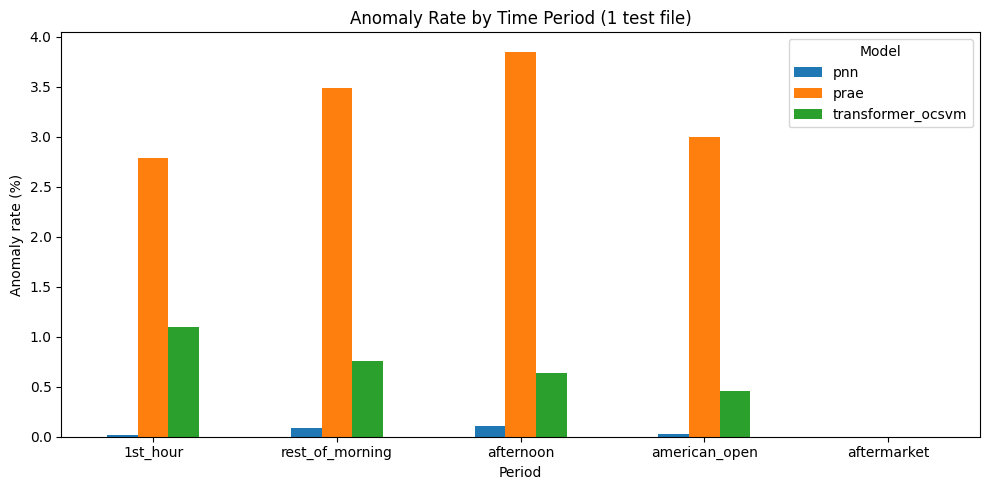

In [6]:
rows = []
for mt in MODEL_TYPES:
    preds = all_preds[mt]
    n = min(len(preds), len(period_labels_seq))
    for period_name in PERIODS:
        mask = period_labels_seq[:n] == period_name
        total = mask.sum()
        if total == 0:
            continue
        n_anom = preds[:n][mask].sum()
        rows.append({
            "Model": mt,
            "Period": period_name,
            "Total": int(total),
            "Anomalies": int(n_anom),
            "Rate (%)": round(100 * n_anom / total, 2),
        })

period_df = pd.DataFrame(rows)
pivot = period_df.pivot_table(index="Period", columns="Model", values="Rate (%)", aggfunc="first")
pivot = pivot.reindex([p for p in PERIODS])

n_days = len(TEST_FILES)
print(f"Anomaly rate (%) by period and model (cumulated over {n_days} test file{'s' if n_days > 1 else ''}):")
display(pivot)

ax = pivot.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylabel("Anomaly rate (%)")
ax.set_title(f"Anomaly Rate by Time Period ({n_days} test file{'s' if n_days > 1 else ''})")
ax.legend(title="Model")
plt.tight_layout()
plt.show()

## Anomaly Score Visualization

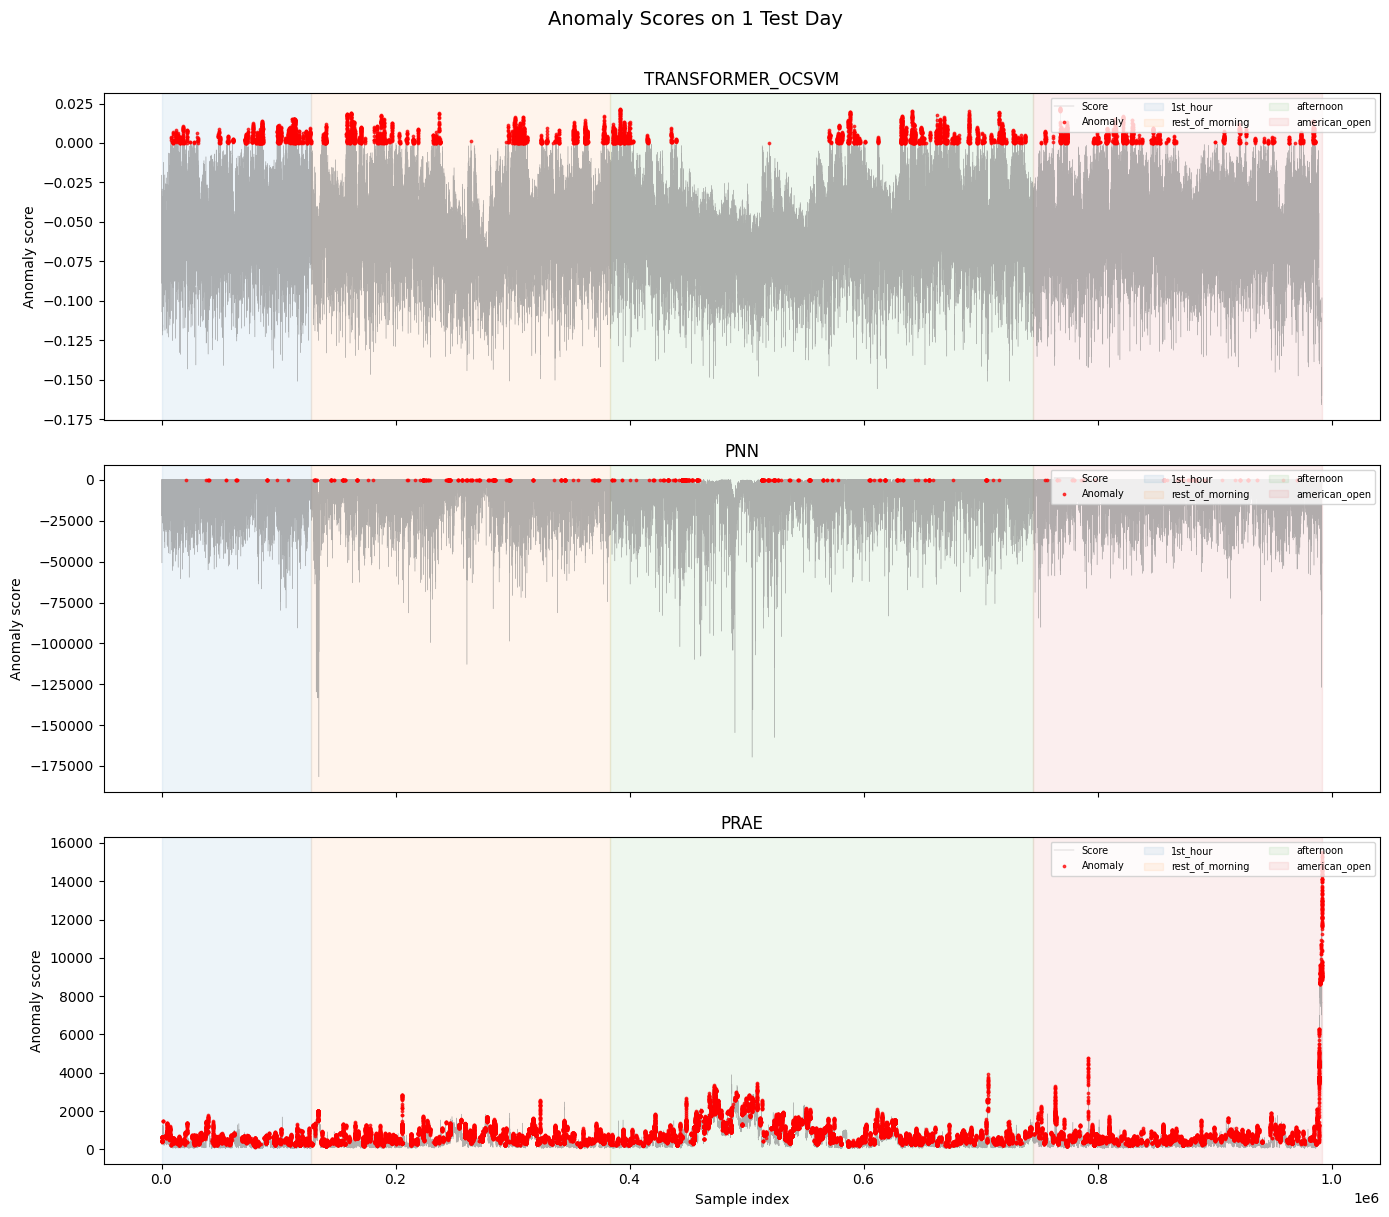

In [7]:
fig, axes = plt.subplots(len(MODEL_TYPES), 1, figsize=(14, 4 * len(MODEL_TYPES)), sharex=True)
if len(MODEL_TYPES) == 1:
    axes = [axes]

colors = {"1st_hour": "#1f77b4", "rest_of_morning": "#ff7f0e",
          "afternoon": "#2ca02c", "american_open": "#d62728",
          "aftermarket": "#9467bd"}

for ax, mt in zip(axes, MODEL_TYPES):
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(period_labels_seq))

    ax.plot(range(n), scores[:n], linewidth=0.3, alpha=0.6, color="grey", label="Score")

    anom_idx = np.where(preds[:n] == 1)[0]
    if len(anom_idx) > 0:
        ax.scatter(anom_idx, scores[anom_idx], s=3, c="red", zorder=3, label="Anomaly", alpha=0.7)

    for period_name, color in colors.items():
        mask = period_labels_seq[:n] == period_name
        if mask.any():
            indices = np.where(mask)[0]
            ax.axvspan(indices[0], indices[-1], alpha=0.08, color=color, label=period_name)

    for b_idx, boundary in enumerate(day_boundaries[1:-1], start=1):
        if boundary < n:
            ax.axvline(boundary, color="black", linestyle="--", linewidth=0.8,
                       alpha=0.5, label="Day boundary" if b_idx == 1 else None)

    ax.set_ylabel("Anomaly score")
    ax.set_title(f"{mt.upper()}")
    ax.legend(loc="upper right", fontsize=7, ncol=3)

axes[-1].set_xlabel("Sample index")
n_days = len(TEST_FILES)
plt.suptitle(f"Anomaly Scores on {n_days} Test Day{'s' if n_days > 1 else ''}", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## Root Cause Analysis

For each model, examine the **top anomaly** and the **top 10% anomalies** to identify which features contribute the most. We compare the feature values at anomalous time steps against the non-anomalous baseline (mean + std).

In [8]:
feat_cols = feat_values_seq.columns.tolist()

for mt in MODEL_TYPES:
    scores = all_scores[mt]
    preds = all_preds[mt]
    n = min(len(scores), len(feat_values_seq))

    print(f"\nROOT CAUSE ANALYSIS: {mt.upper()}")

    top_idx = np.argmax(scores[:n])
    top_score = scores[top_idx]
    top_period = period_labels_seq[top_idx] if top_idx < len(period_labels_seq) else "?"
    top_day = next((d for d, (lo, hi) in enumerate(zip(day_boundaries[:-1], day_boundaries[1:])) if lo <= top_idx < hi), 0)
    print(f"\n  Top anomaly at index {top_idx} (day: {day_names[top_day]}, period: {top_period}, score: {top_score:.4f})")

    normal_mask = preds[:n] == 0
    if normal_mask.sum() > 10:
        normal_mean = feat_values_seq.iloc[:n][normal_mask].mean()
        normal_std = feat_values_seq.iloc[:n][normal_mask].std().replace(0, 1e-10)
        top_feat = feat_values_seq.iloc[top_idx]
        z_scores = ((top_feat - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"\n  Top 10 features by |z-score| at the top anomaly:")
        for feat_name, z in z_scores.head(10).items():
            val = top_feat[feat_name]
            print(f"    {feat_name:45s}  z={z:7.2f}  val={val:10.4f}")

    threshold_10pct = np.percentile(scores[:n], 90)
    top10_mask = scores[:n] >= threshold_10pct
    n_top10 = top10_mask.sum()
    print(f"\n  Top 10% anomalies ({n_top10} samples, score >= {threshold_10pct:.4f}):")

    if normal_mask.sum() > 10:
        top10_feats = feat_values_seq.iloc[:n][top10_mask]
        top10_mean = top10_feats.mean()
        diff = ((top10_mean - normal_mean) / normal_std).abs().sort_values(ascending=False)
        print(f"  Top 10 features by mean |z-score| deviation:")
        for feat_name, d in diff.head(10).items():
            print(f"    {feat_name:45s}  mean_z={d:7.2f}  "
                  f"anom_mean={top10_mean[feat_name]:10.4f}  "
                  f"normal_mean={normal_mean[feat_name]:10.4f}")

    if len(period_labels_seq) >= n:
        top10_periods = pd.Series(period_labels_seq[:n][top10_mask]).value_counts()
        print(f"\n  Period distribution of top 10% anomalies:")
        for p, cnt in top10_periods.items():
            print(f"    {p:25s}  {cnt:5d}")

print("\nRoot cause analysis complete.")


ROOT CAUSE ANALYSIS: TRANSFORMER_OCSVM

  Top anomaly at index 768297 (day: 2015-01-07-TOTF.PA-book.parquet, period: american_open, score: 0.0222)

  Top 10 features by |z-score| at the top anomaly:
    log_dt                                         z=   2.21  val=  -12.4562
    dt                                             z=   1.39  val=    0.0000
    price_range_50                                 z=   0.90  val=    0.0000
    mid_price_volatility                           z=   0.88  val=    0.0000
    volatility_50                                  z=   0.86  val=    0.0000
    Hawkes_M_ask_beta100                           z=   0.83  val=   15.4356
    Hawkes_M_bid_beta1000                          z=   0.76  val=   31.8541
    order_flow_imbalance_level_2                   z=   0.74  val=  364.0000
    Hawkes_M_bid_beta10                            z=   0.63  val=    2.0692
    Hawkes_M_ask_beta10                            z=   0.62  val=    4.2374

  Top 10% anomalies (99182 sa

## Consensus Anomaly Analysis

For every sample, count how many of the three models flag it as anomalous:
- Unanimous (3/3)
- Majority (2/3)
- Single-model (1/3)

Model agreement distribution:


,Models Agreeing,Sample Count,Pct (%)
0,0,950545,95.839
1,1,41213,4.155
2,2,54,0.005


2026-03-04 23:31:21,050 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-04 23:31:21,050 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Pairwise overlap (samples flagged by two models):
  transformer_ocsvm & pnn: 0
  transformer_ocsvm & prae: 1
  pnn & prae: 53

Unanimous (3/3): 0 samples (0.000%)
Majority  (>=2/3): 54 samples (0.005%)


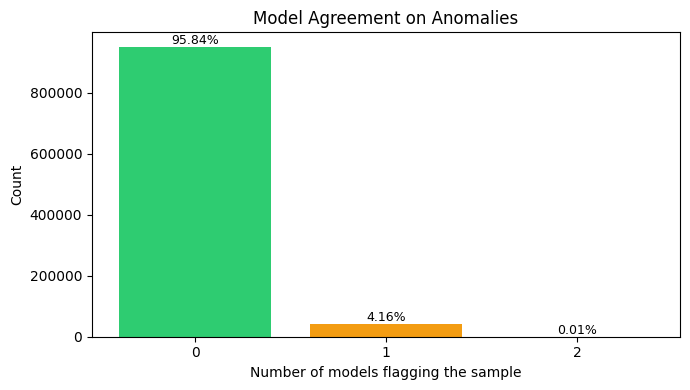

In [9]:
from itertools import combinations

n_total = min(len(all_preds[mt]) for mt in MODEL_TYPES)

pred_matrix = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged = pred_matrix.sum(axis=1)

agreement_counts = pd.Series(n_models_flagged).value_counts().sort_index()
agreement_counts.index.name = "# Models flagging"
agreement_df = agreement_counts.reset_index()
agreement_df.columns = ["Models Agreeing", "Sample Count"]
agreement_df["Pct (%)"] = (100 * agreement_df["Sample Count"] / n_total).round(3)
print("Model agreement distribution:")
display(agreement_df)

print("\nPairwise overlap (samples flagged by two models):")
for m1, m2 in combinations(MODEL_TYPES, 2):
    overlap = (all_preds[m1][:n_total] & all_preds[m2][:n_total]).sum()
    print(f"  {m1} & {m2}: {overlap}")

n_unanimous = (n_models_flagged == 3).sum()
n_majority  = (n_models_flagged >= 2).sum()
print(f"\nUnanimous (3/3): {n_unanimous} samples ({100*n_unanimous/n_total:.3f}%)")
print(f"Majority  (>=2/3): {n_majority} samples ({100*n_majority/n_total:.3f}%)")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(agreement_df["Models Agreeing"].astype(str), agreement_df["Sample Count"], color=["#2ecc71", "#f39c12", "#e74c3c", "#8e44ad"])
ax.set_xlabel("Number of models flagging the sample")
ax.set_ylabel("Count")
ax.set_title("Model Agreement on Anomalies")
for bar, pct in zip(bars, agreement_df["Pct (%)"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{pct:.2f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## LOB Deep Dive: Top Anomalies

For the **top anomaly of each model** and the **top consensus anomaly** (if any):
1. Reconstruct the raw limit order book around the event.
2. Visualise the order book depth (bid/ask volumes across 10 levels).
3. Show how key features evolve through the anomaly window.
4. Highlight the exact anomaly timestamp.

In [10]:
raw_lob_days = []
raw_features_days = []
for test_file in TEST_FILES:
    df_raw, feat_raw = load_processed(test_file)
    raw_lob_days.append(df_raw)
    raw_features_days.append(feat_raw)
    print(f"Loaded {os.path.basename(test_file)}: {len(df_raw)} raw rows, {len(feat_raw)} feature rows")

Loaded 2015-01-07-TOTF.PA-book.parquet: 991837 raw rows, 991837 feature rows


In [11]:
LOB_LEVELS = 10
CONTEXT_WINDOW = 50

from sklearn.preprocessing import MinMaxScaler

norm_matrix = np.column_stack([
    MinMaxScaler().fit_transform(all_scores[mt][:n_total].reshape(-1, 1)).flatten()
    for mt in MODEL_TYPES
])

def seq_idx_to_raw(seq_idx, day_boundaries, warmup=WARMUP_STEPS, seq_len=SEQ_LENGTH):
    """Convert a global sequence index to (day_id, raw_lob_row_index)."""
    for day_id, (lo, hi) in enumerate(zip(day_boundaries[:-1], day_boundaries[1:])):
        if lo <= seq_idx < hi:
            local_idx = seq_idx - lo
            raw_row = warmup + seq_len + local_idx
            return day_id, raw_row
    return 0, warmup + seq_len + seq_idx

anomalies_to_inspect = {}

for mt in MODEL_TYPES:
    scores = all_scores[mt][:n_total]
    top_idx = int(np.argmax(scores))
    day_id, raw_row = seq_idx_to_raw(top_idx, day_boundaries)
    anomalies_to_inspect[f"Top {mt}"] = {
        "seq_idx": top_idx, "day_id": day_id, "raw_row": raw_row,
        "score": scores[top_idx], "model": mt,
    }

if n_unanimous > 0:
    consensus_mask = n_models_flagged == 3
elif n_majority > 0:
    consensus_mask = n_models_flagged >= 2
else:
    consensus_mask = n_models_flagged >= 1

if consensus_mask.any():
    consensus_indices = np.where(consensus_mask)[0]
    consensus_total_score = norm_matrix[consensus_indices].sum(axis=1)
    best_consensus_local = int(np.argmax(consensus_total_score))
    best_consensus_idx = consensus_indices[best_consensus_local]
    day_id, raw_row = seq_idx_to_raw(best_consensus_idx, day_boundaries)
    n_agree = int(n_models_flagged[best_consensus_idx])
    anomalies_to_inspect[f"Top Consensus ({n_agree}/3)"] = {
        "seq_idx": best_consensus_idx, "day_id": day_id, "raw_row": raw_row,
        "score": float(consensus_total_score[best_consensus_local]),
        "model": "consensus",
    }

print("Anomalies selected for deep dive:")
for label, info in anomalies_to_inspect.items():
    period = period_labels_seq[info["seq_idx"]] if info["seq_idx"] < len(period_labels_seq) else "?"
    print(f"  {label:40s} | day={day_names[info['day_id']][:15]:15s} | "
          f"raw_row={info['raw_row']:6d} | period={period:20s} | score={info['score']:.4f}")

Anomalies selected for deep dive:
  Top transformer_ocsvm                    | day=2015-01-07-TOTF | raw_row=771322 | period=american_open        | score=0.0222
  Top pnn                                  | day=2015-01-07-TOTF | raw_row=450284 | period=afternoon            | score=0.0000
  Top prae                                 | day=2015-01-07-TOTF | raw_row=994547 | period=american_open        | score=15530.7197
  Top Consensus (2/3)                      | day=2015-01-07-TOTF | raw_row=810402 | period=american_open        | score=1.9089



Top transformer_ocsvm
  Day: 2015-01-07-TOTF.PA-book.parquet | Raw row: 771322 | Score: 0.0222


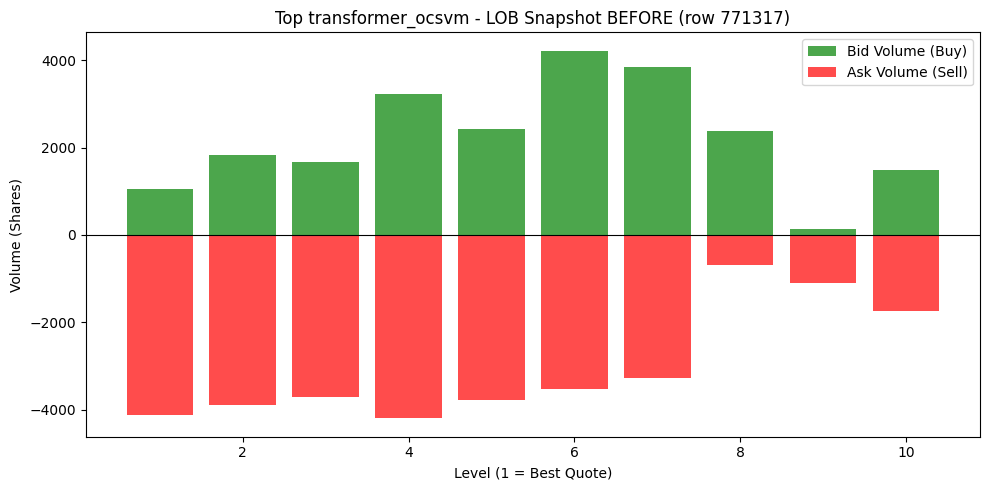

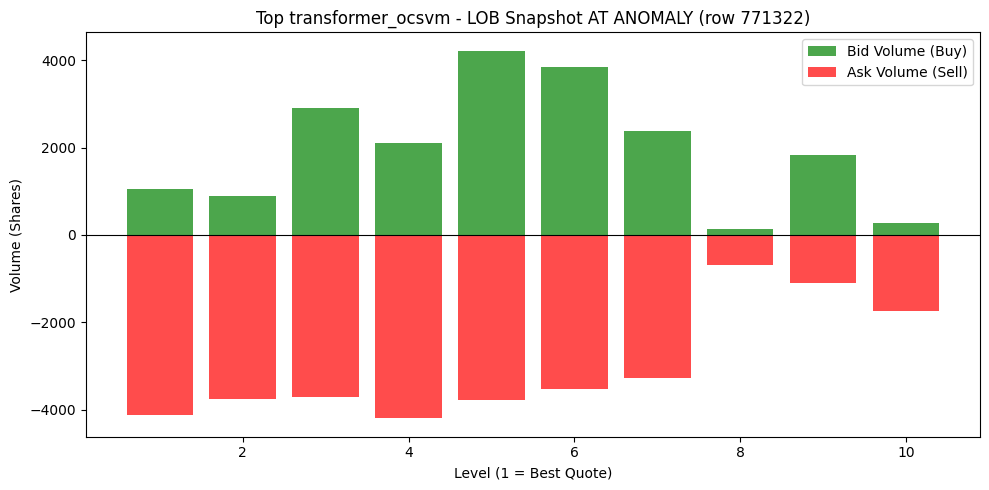

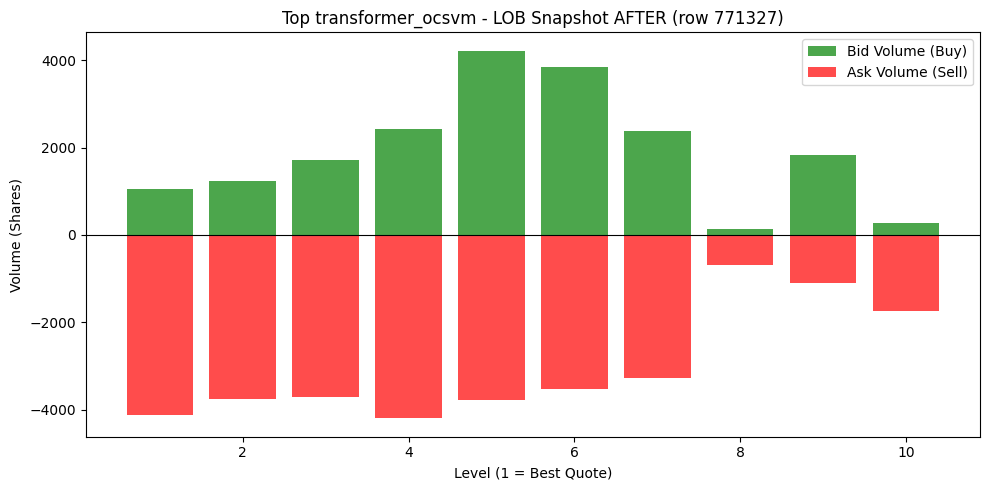

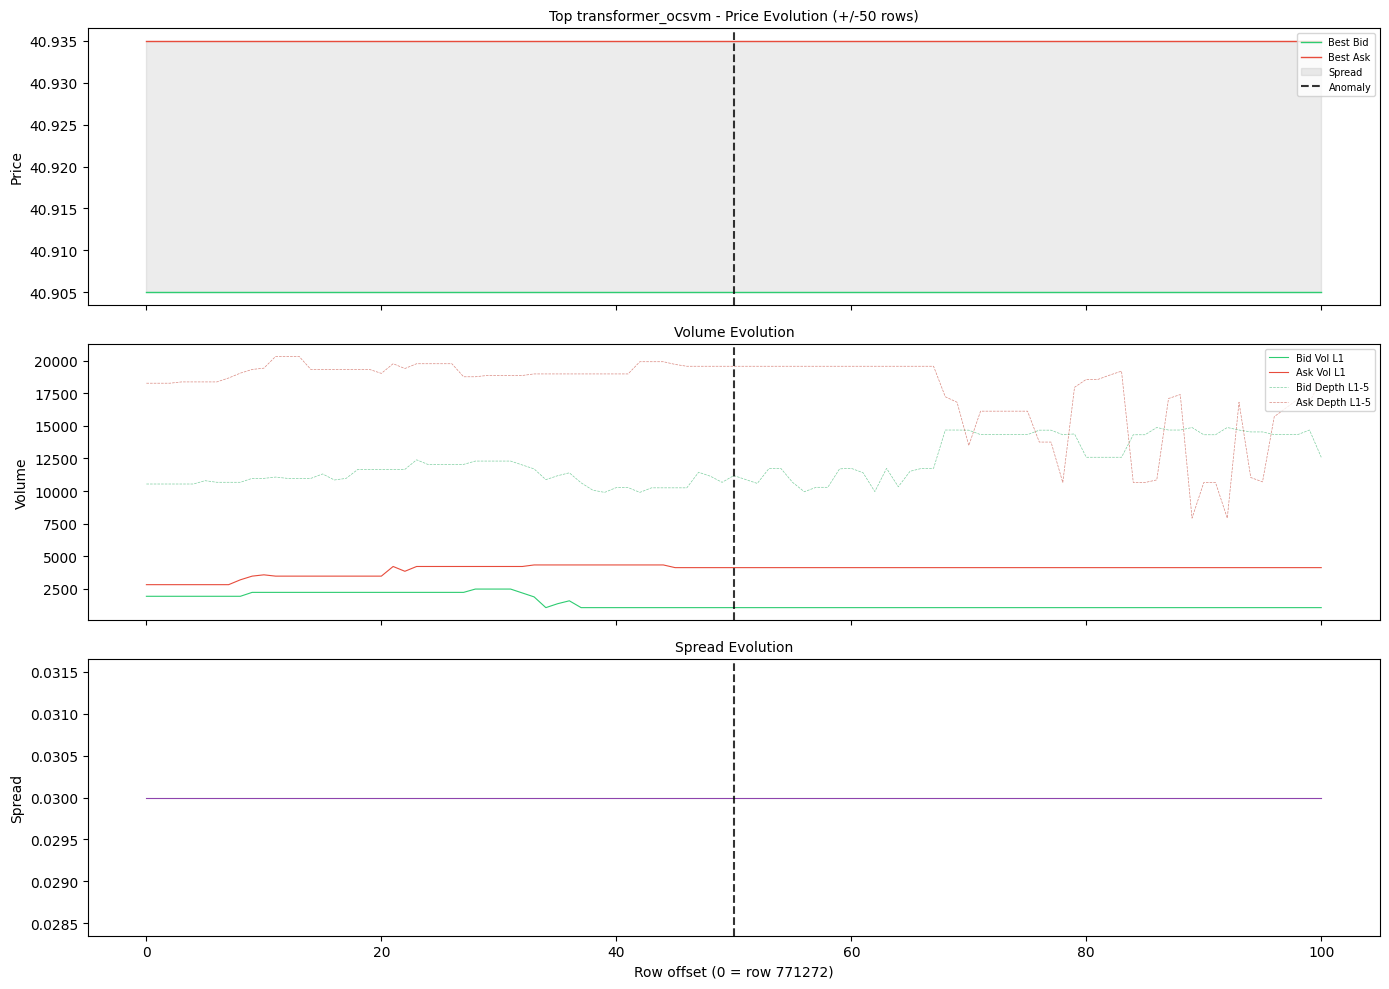


Top pnn
  Day: 2015-01-07-TOTF.PA-book.parquet | Raw row: 450284 | Score: 0.0000


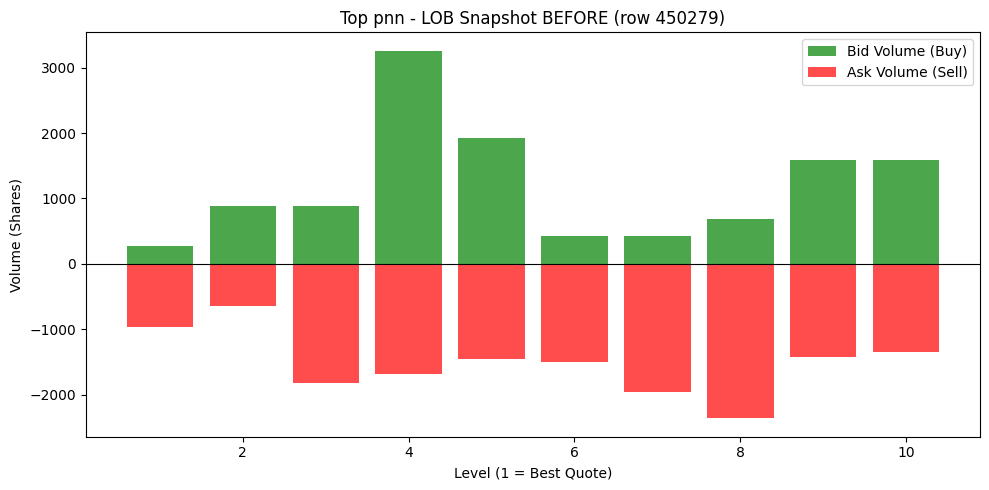

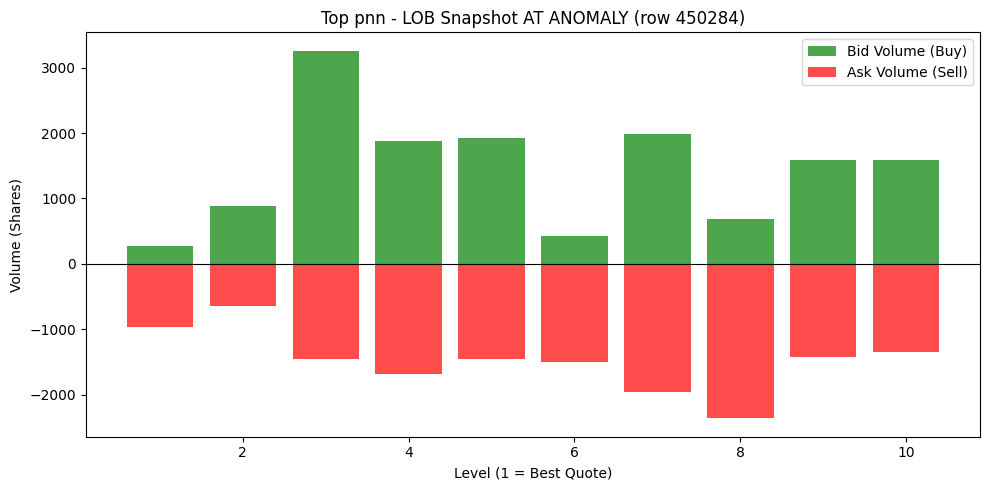

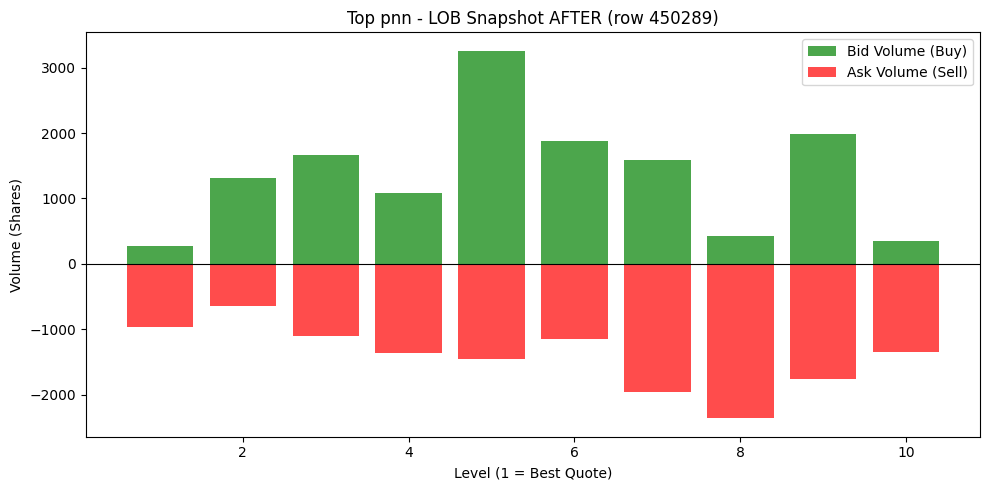

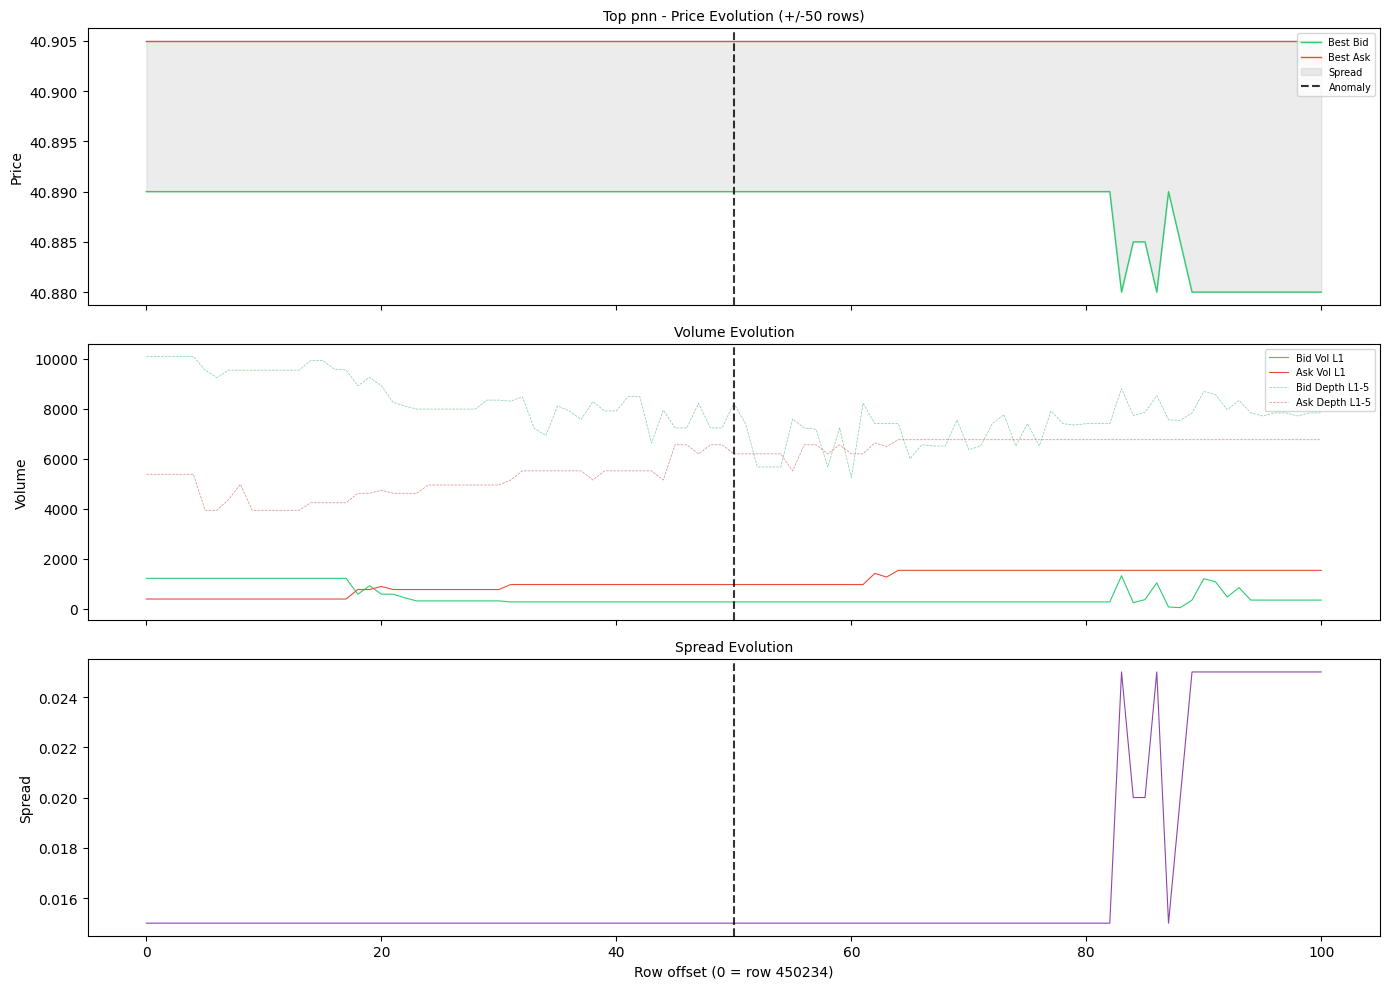


Top prae
  Day: 2015-01-07-TOTF.PA-book.parquet | Raw row: 991836 | Score: 15530.7197


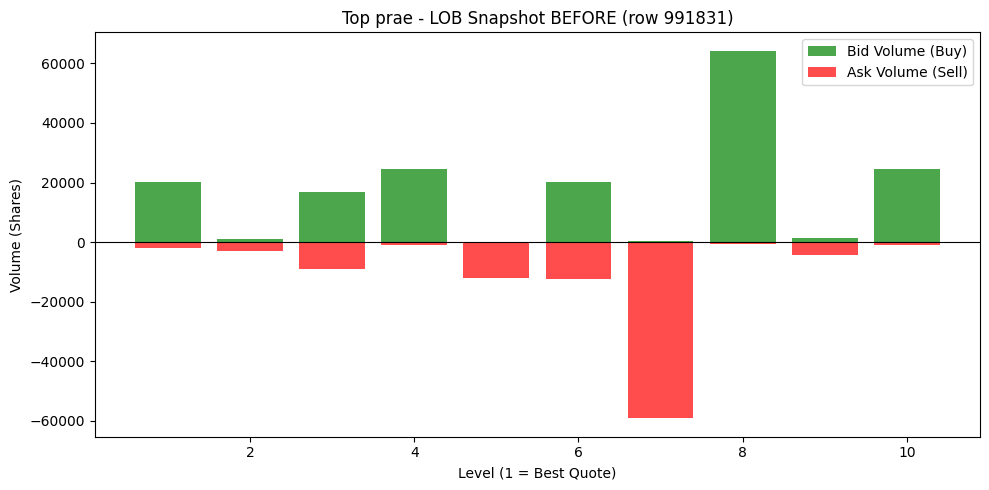

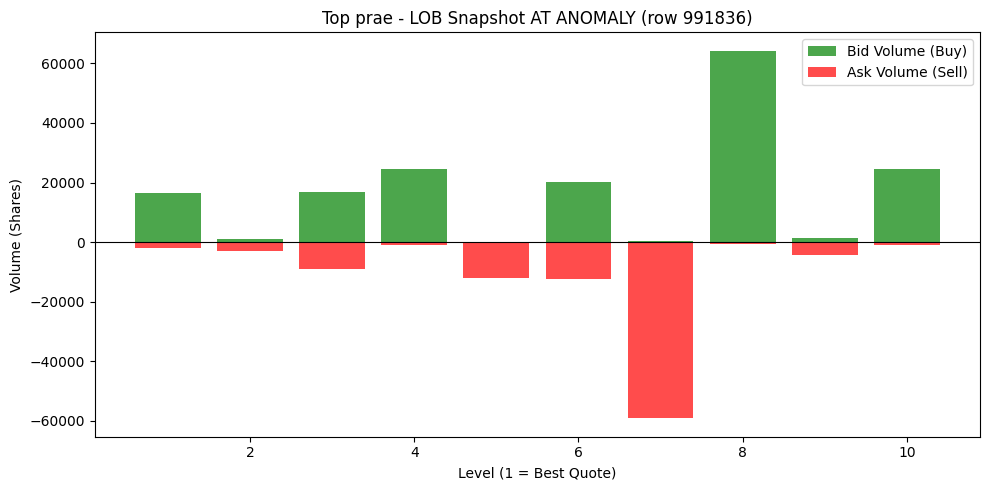

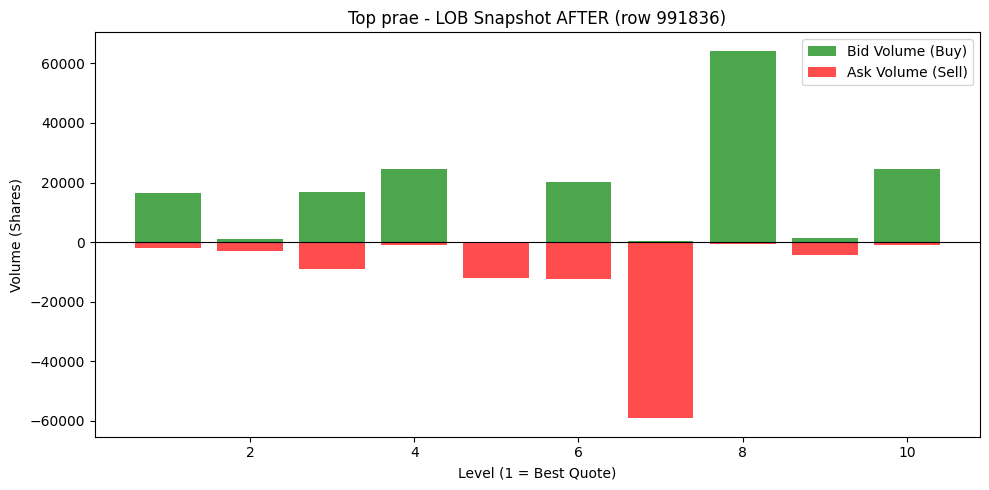

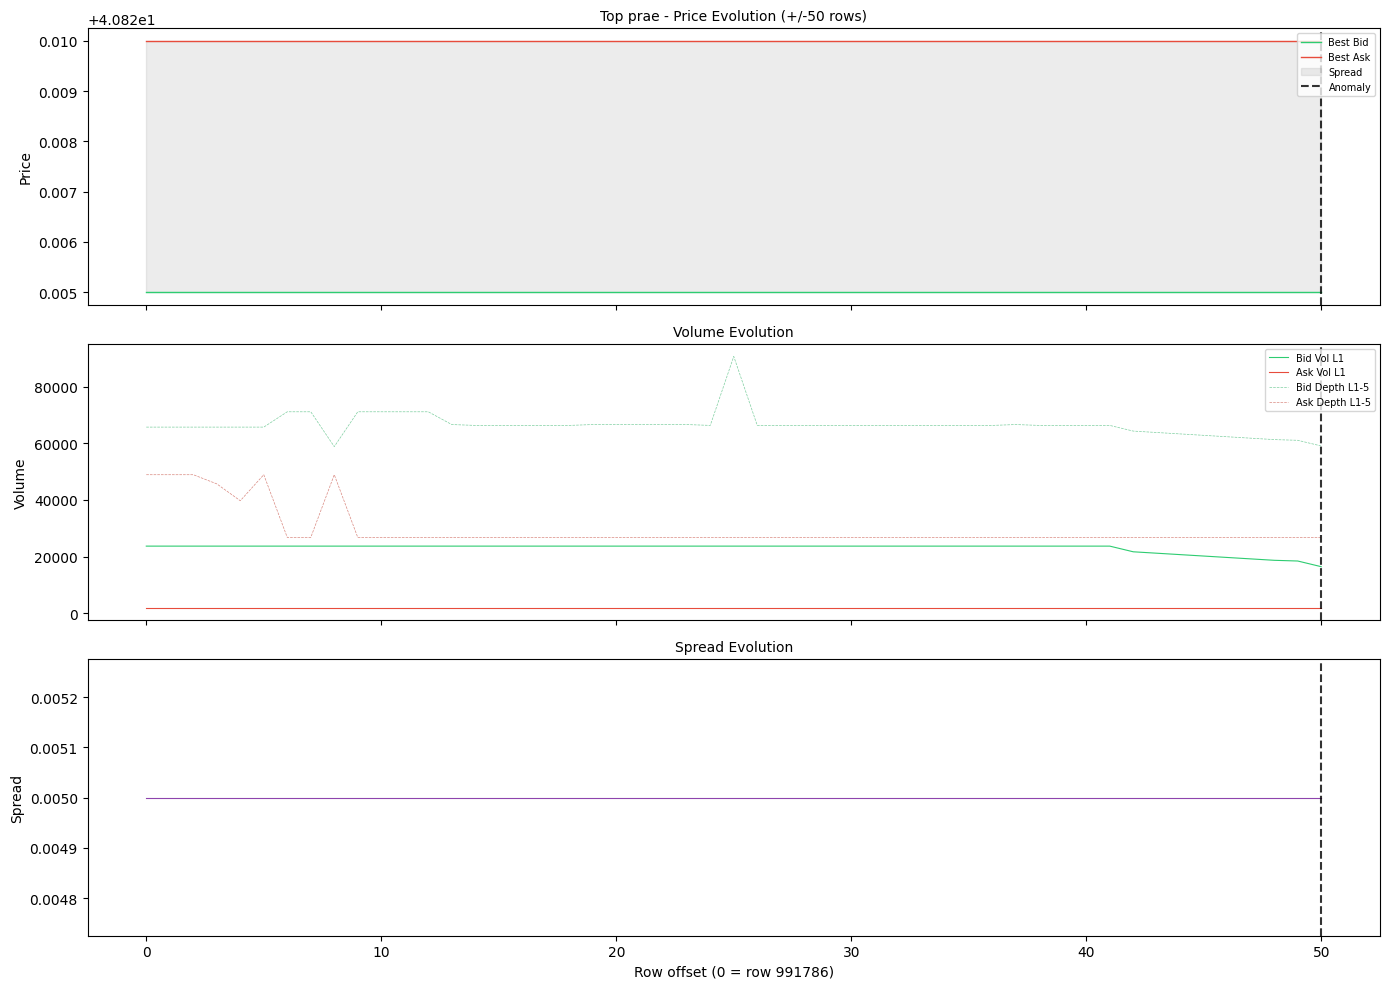


Top Consensus (2/3)
  Day: 2015-01-07-TOTF.PA-book.parquet | Raw row: 810402 | Score: 1.9089


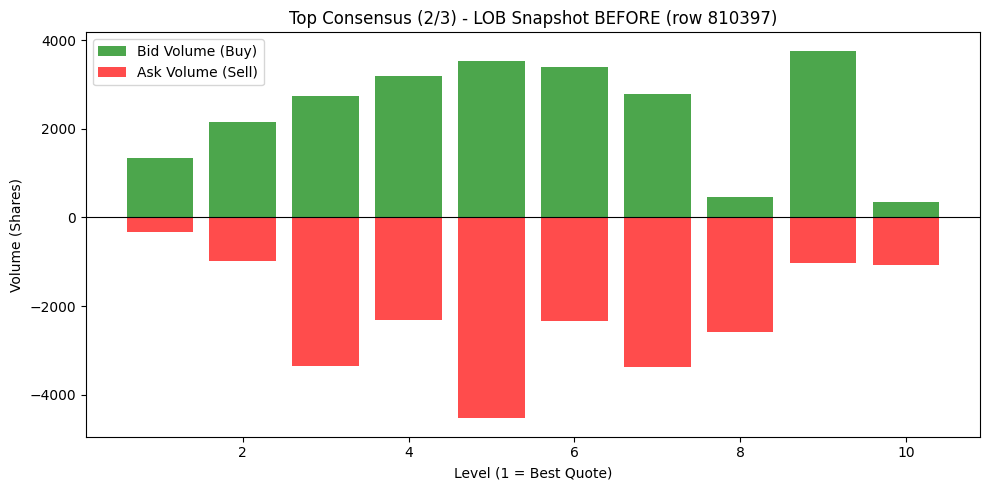

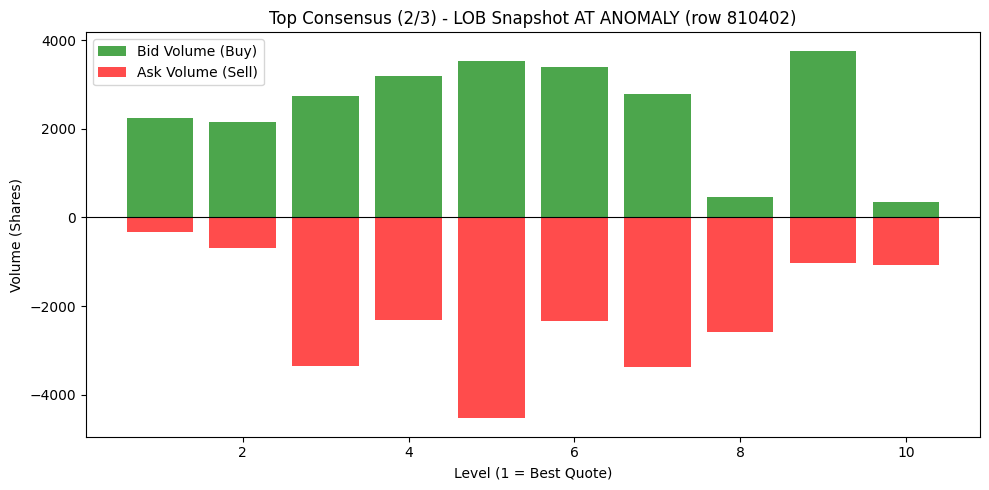

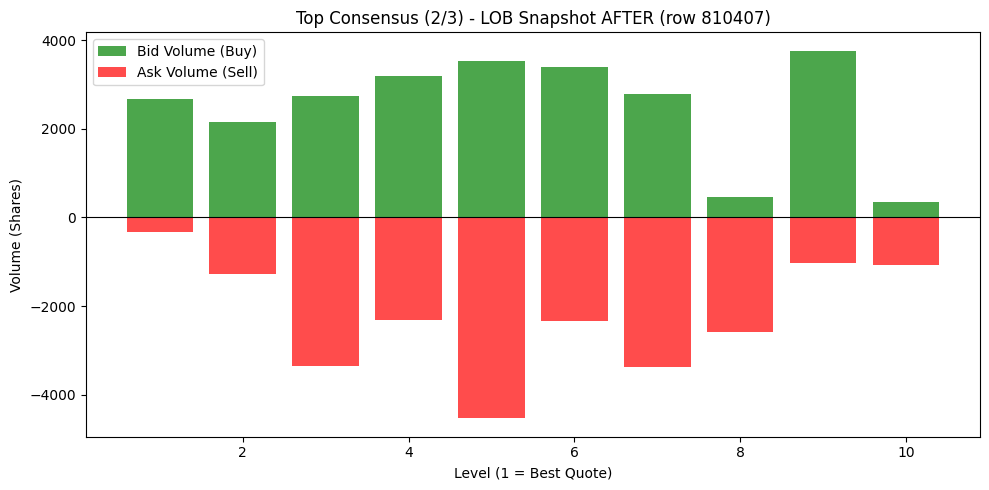

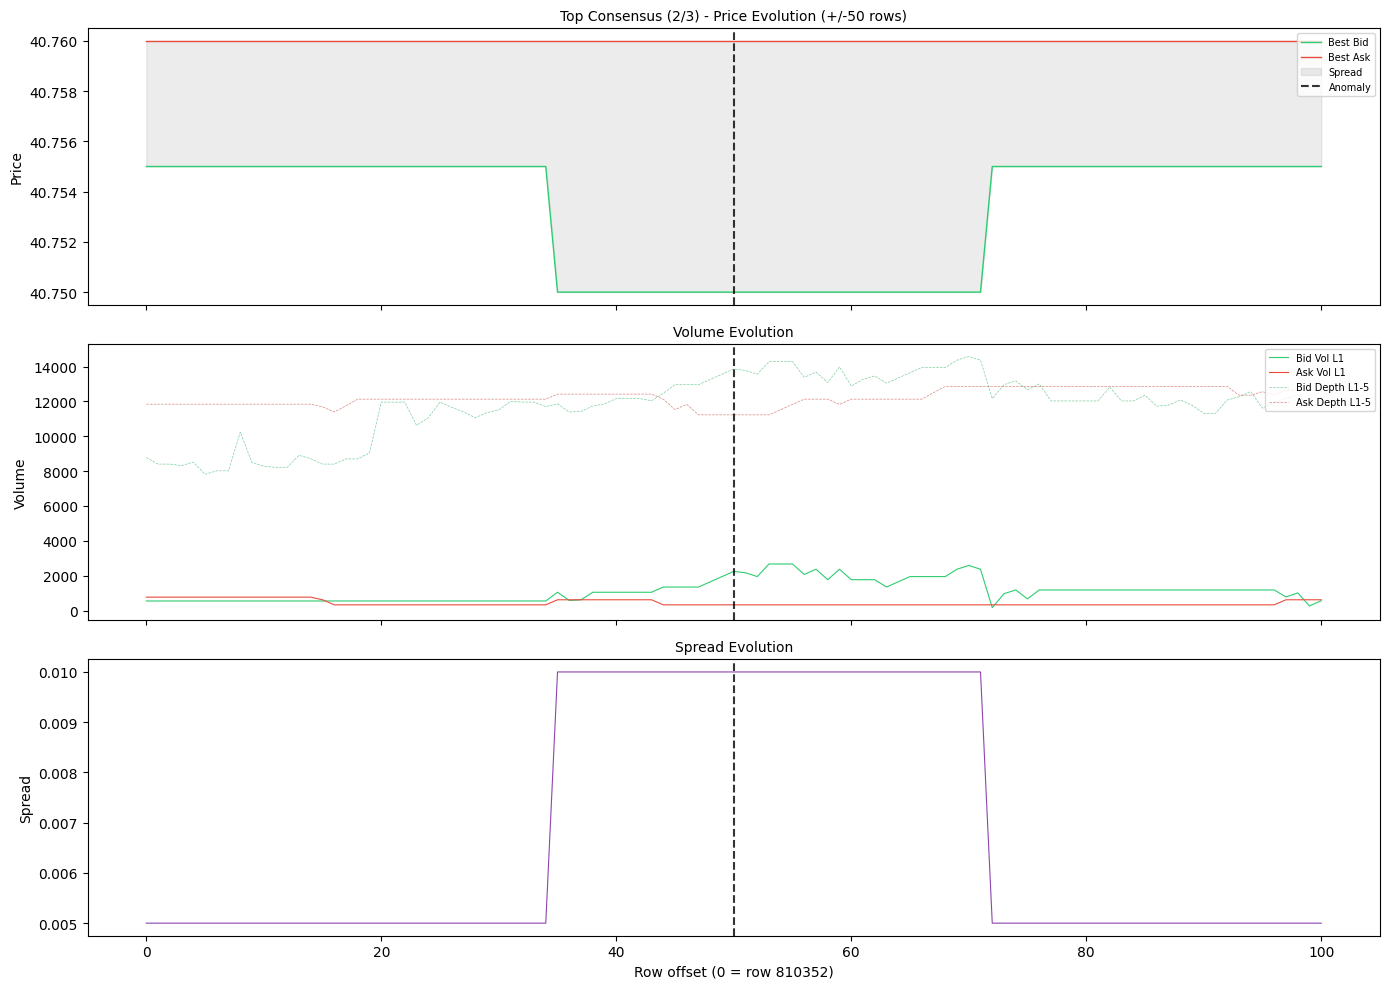

In [12]:
def plot_lob_snapshot(df_raw, center_row, title="", n_levels=LOB_LEVELS):
    """Visualises the Order Book shape at a specific row using vertical bars."""
    row = df_raw.iloc[center_row]

    bids = [row.get(f"bid-volume-{i}", 0) for i in range(1, n_levels + 1)]
    asks = [row.get(f"ask-volume-{i}", 0) for i in range(1, n_levels + 1)]

    x = np.arange(1, n_levels + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, bids, color="green", label="Bid Volume (Buy)", alpha=0.7)
    ax.bar(x, [-a for a in asks], color="red", label="Ask Volume (Sell)", alpha=0.7)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Level (1 = Best Quote)")
    ax.set_ylabel("Volume (Shares)")
    ax.set_title(title if title else f"LOB Snapshot at Row {center_row}")
    ax.legend()
    plt.tight_layout()
    return fig


def plot_lob_evolution(df_raw, center_row, window=CONTEXT_WINDOW, title=""):
    """Plot bid/ask price and volume evolution around the anomaly."""
    start = max(0, center_row - window)
    end = min(len(df_raw), center_row + window + 1)
    subset = df_raw.iloc[start:end].copy()
    x = np.arange(len(subset))
    anomaly_x = center_row - start

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(x, subset["bid-price-1"], color="#2ecc71", linewidth=1, label="Best Bid")
    ax.plot(x, subset["ask-price-1"], color="#e74c3c", linewidth=1, label="Best Ask")
    ax.fill_between(x, subset["bid-price-1"], subset["ask-price-1"], alpha=0.15, color="grey", label="Spread")
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8, label="Anomaly")
    ax.set_ylabel("Price")
    ax.set_title(f"{title} - Price Evolution (+/-{window} rows)", fontsize=10)
    ax.legend(loc="upper right", fontsize=7)

    ax = axes[1]
    ax.plot(x, subset["bid-volume-1"], color="#2ecc71", linewidth=0.8, label="Bid Vol L1")
    ax.plot(x, subset["ask-volume-1"], color="#e74c3c", linewidth=0.8, label="Ask Vol L1")
    bid_depth_5 = sum(subset.get(f"bid-volume-{i+1}", 0) for i in range(5))
    ask_depth_5 = sum(subset.get(f"ask-volume-{i+1}", 0) for i in range(5))
    ax.plot(x, bid_depth_5, color="#27ae60", linewidth=0.5, linestyle="--", alpha=0.6, label="Bid Depth L1-5")
    ax.plot(x, ask_depth_5, color="#c0392b", linewidth=0.5, linestyle="--", alpha=0.6, label="Ask Depth L1-5")
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_ylabel("Volume")
    ax.set_title("Volume Evolution", fontsize=10)
    ax.legend(loc="upper right", fontsize=7)

    ax = axes[2]
    spread = subset["ask-price-1"] - subset["bid-price-1"]
    ax.plot(x, spread, color="#8e44ad", linewidth=0.8)
    ax.axvline(anomaly_x, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_ylabel("Spread")
    ax.set_xlabel(f"Row offset (0 = row {start})")
    ax.set_title("Spread Evolution", fontsize=10)

    plt.tight_layout()
    return fig


for label, info in anomalies_to_inspect.items():
    day_id = info["day_id"]
    raw_row = info["raw_row"]
    df_raw = raw_lob_days[day_id]
    raw_row = min(raw_row, len(df_raw) - 1)

    print(f"\n{label}")
    print(f"  Day: {day_names[day_id]} | Raw row: {raw_row} | Score: {info['score']:.4f}")

    before_row = max(0, raw_row - 5)
    plot_lob_snapshot(df_raw, before_row,
                      title=f"{label} - LOB Snapshot BEFORE (row {before_row})")
    plt.show()

    plot_lob_snapshot(df_raw, raw_row,
                      title=f"{label} - LOB Snapshot AT ANOMALY (row {raw_row})")
    plt.show()

    after_row = min(len(df_raw) - 1, raw_row + 5)
    plot_lob_snapshot(df_raw, after_row,
                      title=f"{label} - LOB Snapshot AFTER (row {after_row})")
    plt.show()

    plot_lob_evolution(df_raw, raw_row, window=CONTEXT_WINDOW, title=label)
    plt.show()

## Feature Evolution Around Anomalies

For each top anomaly, examine how the **most anomalous features** (by z-score) evolve in a window around the event:
- Whether features spike suddenly (impulsive manipulation) or drift gradually.
- Which features jump first (potential leading indicators).
- How quickly the book recovers after the anomalous state.


FEATURE EVOLUTION: Top transformer_ocsvm
Top 8 features by |z-score| at anomaly:
  log_dt                                    z=   2.21  val=-12.456198
  dt                                        z=   1.39  val=0.000003
  price_range_50                            z=   0.90  val=0.000000
  mid_price_volatility                      z=   0.88  val=0.000000
  volatility_50                             z=   0.86  val=0.000000
  Hawkes_M_ask_beta100                      z=   0.83  val=15.435638
  Hawkes_M_bid_beta1000                     z=   0.76  val=31.854052
  order_flow_imbalance_level_2              z=   0.74  val=364.000000


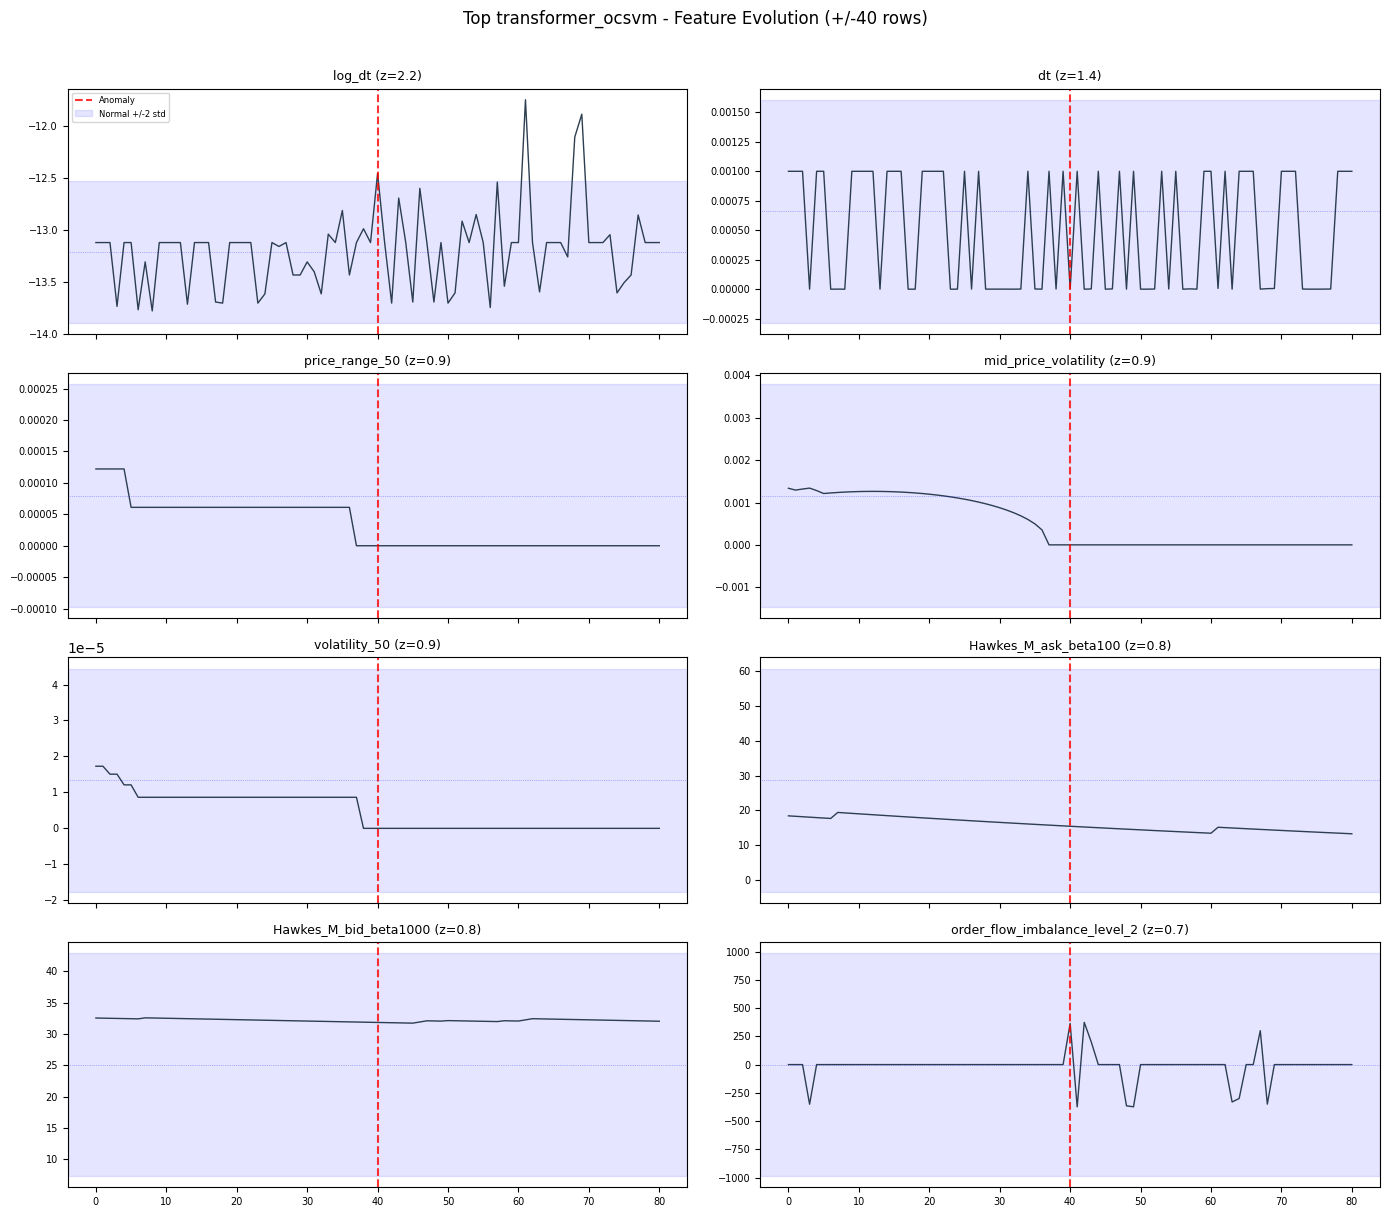


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
log_dt,-12.813211,-13.122363,-12.456198,-13.122363,-13.695672,0.666166,-0.666166
dt,0.000002,0.001000,0.000003,0.001000,0.000000,-0.000997,0.000997
price_range_50,0.000061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mid_price_volatility,0.000495,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
volatility_50,0.000009,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Hawkes_M_ask_beta100,15.979974,15.543001,15.435638,15.329016,14.909843,-0.107363,-0.106622
Hawkes_M_bid_beta1000,31.964642,31.876140,31.854052,31.831980,31.743846,-0.022087,-0.022072
order_flow_imbalance_level_2,0.000000,0.000000,364.000000,-374.000000,0.000000,364.000000,-738.000000



FEATURE EVOLUTION: Top pnn
Top 8 features by |z-score| at anomaly:
  bid_sweep_cost                            z=   4.27  val=0.028500
  spread                                    z=   1.68  val=0.005000
  Hawkes_M_bid_beta1000                     z=   1.37  val=12.996908
  volatility_100                            z=   1.21  val=0.000000
  ask_sweep_cost                            z=   1.19  val=0.005545
  L1_Imbalance                              z=   1.06  val=-0.663830
  Hawkes_L_ask_beta100_Eta0.001             z=   1.00  val=161.096060
  L5_Imbalance                              z=   0.96  val=-0.262632


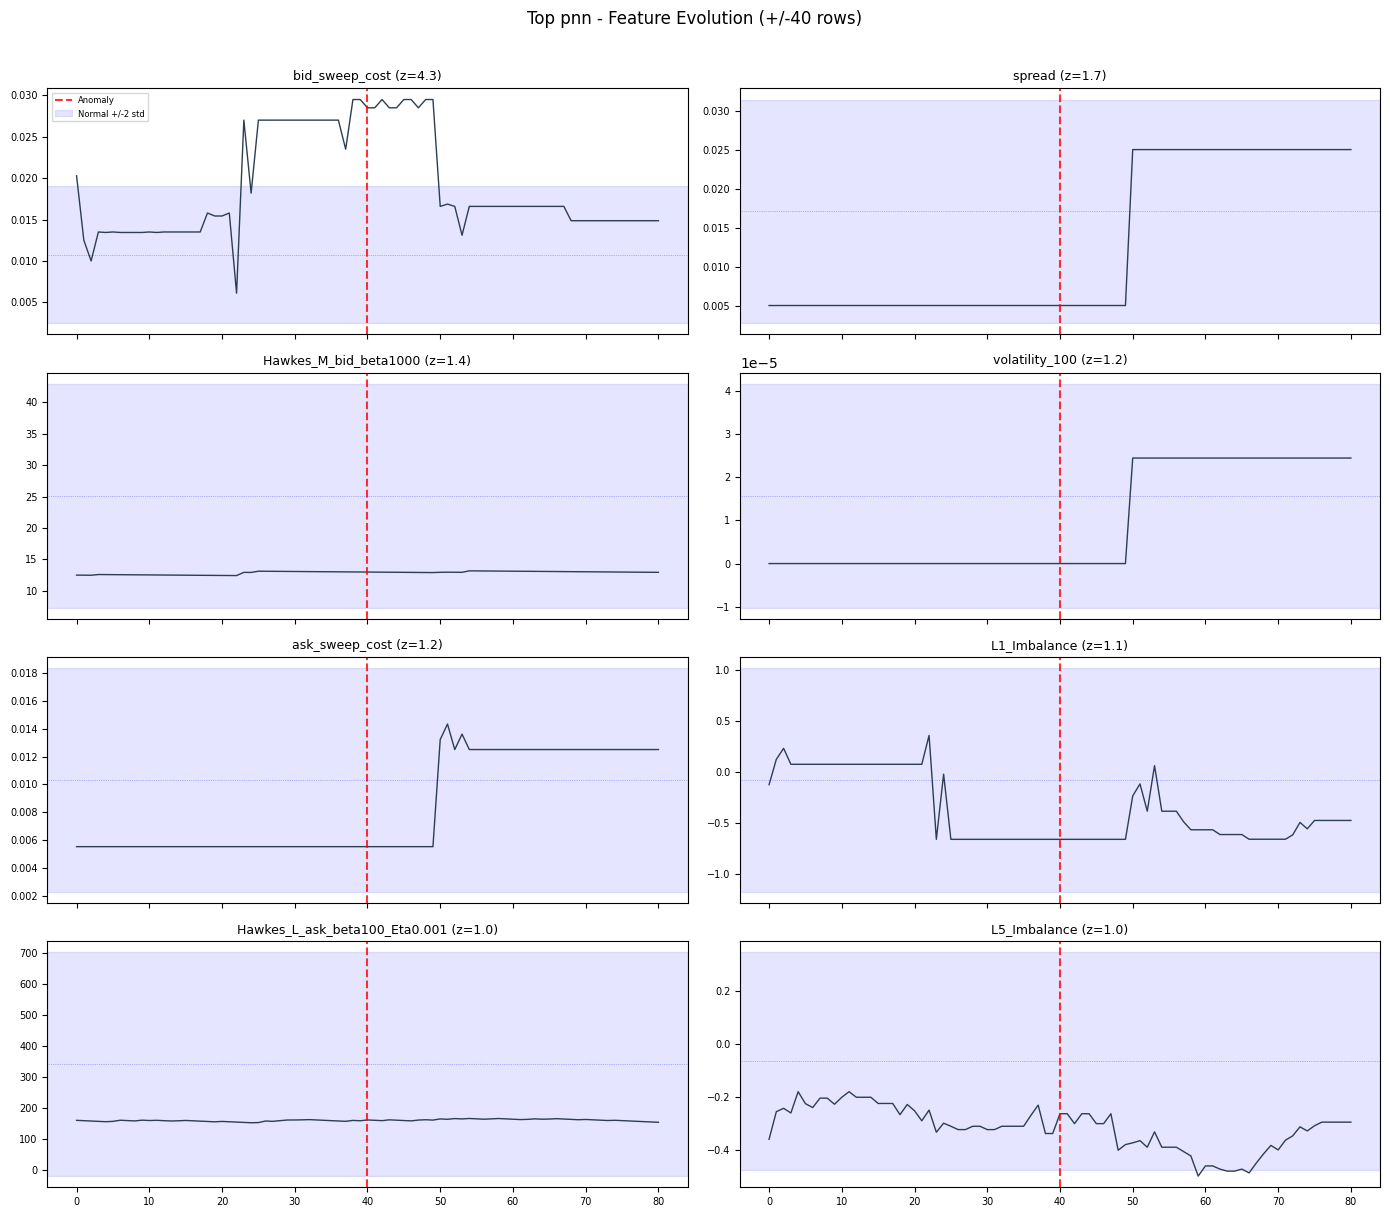


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
bid_sweep_cost,0.027010,0.029500,0.028500,0.028500,0.029500,-0.001000,0.000000
spread,0.005000,0.005000,0.005000,0.005000,0.005000,0.000000,0.000000
Hawkes_M_bid_beta1000,13.042030,13.005920,12.996908,12.987903,12.951942,-0.009012,-0.009006
volatility_100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ask_sweep_cost,0.005545,0.005545,0.005545,0.005545,0.005545,0.000000,0.000000
L1_Imbalance,-0.663830,-0.663830,-0.663830,-0.663830,-0.663830,0.000000,0.000000
Hawkes_L_ask_beta100_Eta0.001,158.848301,158.523850,161.096060,159.983288,159.225263,2.572210,-1.112772
L5_Imbalance,-0.309792,-0.337074,-0.262632,-0.262632,-0.299933,0.074442,0.000000



FEATURE EVOLUTION: Top prae
Top 8 features by |z-score| at anomaly:
  Hawkes_L_bid_beta10_Eta10.0               z=  32.79  val=337.046350
  Hawkes_L_bid_beta10_Eta1.0                z=  32.79  val=337.046350
  Hawkes_L_bid_beta10_Eta0.1                z=  32.56  val=344.698029
  Hawkes_L_ask_beta100_Eta10.0              z=  32.15  val=1129.805082
  Hawkes_L_ask_beta100_Eta1.0               z=  32.15  val=1129.805082
  Hawkes_L_ask_beta100_Eta0.1               z=  32.14  val=1129.805336
  Hawkes_L_ask_beta10_Eta10.0               z=  31.30  val=241.739092
  Hawkes_L_ask_beta10_Eta1.0                z=  31.30  val=241.739092


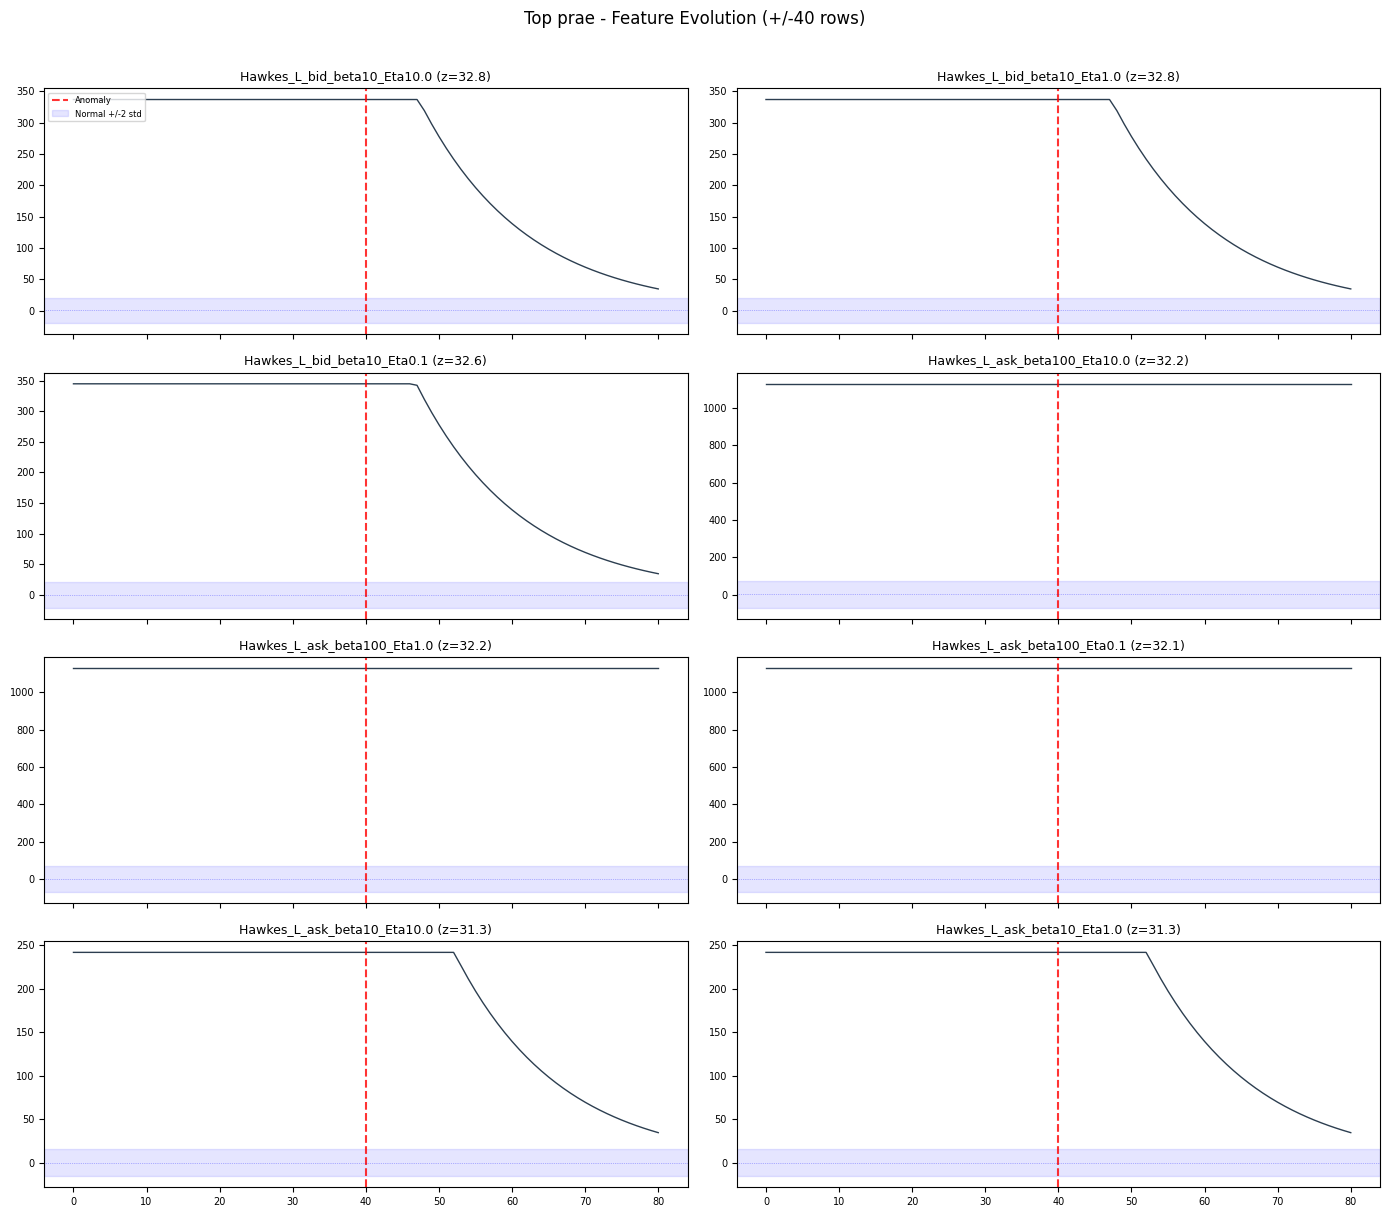


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
Hawkes_L_bid_beta10_Eta10.0,337.046350,337.046350,337.046350,337.046350,337.046350,0.0,0.0
Hawkes_L_bid_beta10_Eta1.0,337.046350,337.046350,337.046350,337.046350,337.046350,0.0,0.0
Hawkes_L_bid_beta10_Eta0.1,344.698029,344.698029,344.698029,344.698029,344.698029,0.0,0.0
Hawkes_L_ask_beta100_Eta10.0,1129.805082,1129.805082,1129.805082,1129.805082,1129.805082,0.0,0.0
Hawkes_L_ask_beta100_Eta1.0,1129.805082,1129.805082,1129.805082,1129.805082,1129.805082,0.0,0.0
Hawkes_L_ask_beta100_Eta0.1,1129.805336,1129.805336,1129.805336,1129.805336,1129.805336,0.0,0.0
Hawkes_L_ask_beta10_Eta10.0,241.739092,241.739092,241.739092,241.739092,241.739092,0.0,0.0
Hawkes_L_ask_beta10_Eta1.0,241.739092,241.739092,241.739092,241.739092,241.739092,0.0,0.0



FEATURE EVOLUTION: Top Consensus (2/3)
Top 8 features by |z-score| at anomaly:
  order_flow_imbalance_level_5              z=   2.83  val=-2744.000000
  order_flow_imbalance_level_3              z=   2.45  val=-1743.000000
  ask_sweep_cost                            z=   1.97  val=0.002500
  order_flow_imbalance_level_4              z=   1.74  val=-1507.000000
  spread                                    z=   1.71  val=0.005000
  Hawkes_L_bid_beta10_Eta0.001              z=   1.32  val=712.735532
  Hawkes_M_ask_beta1000                     z=   0.85  val=35.211451
  L1_Imbalance                              z=   0.83  val=-0.536501


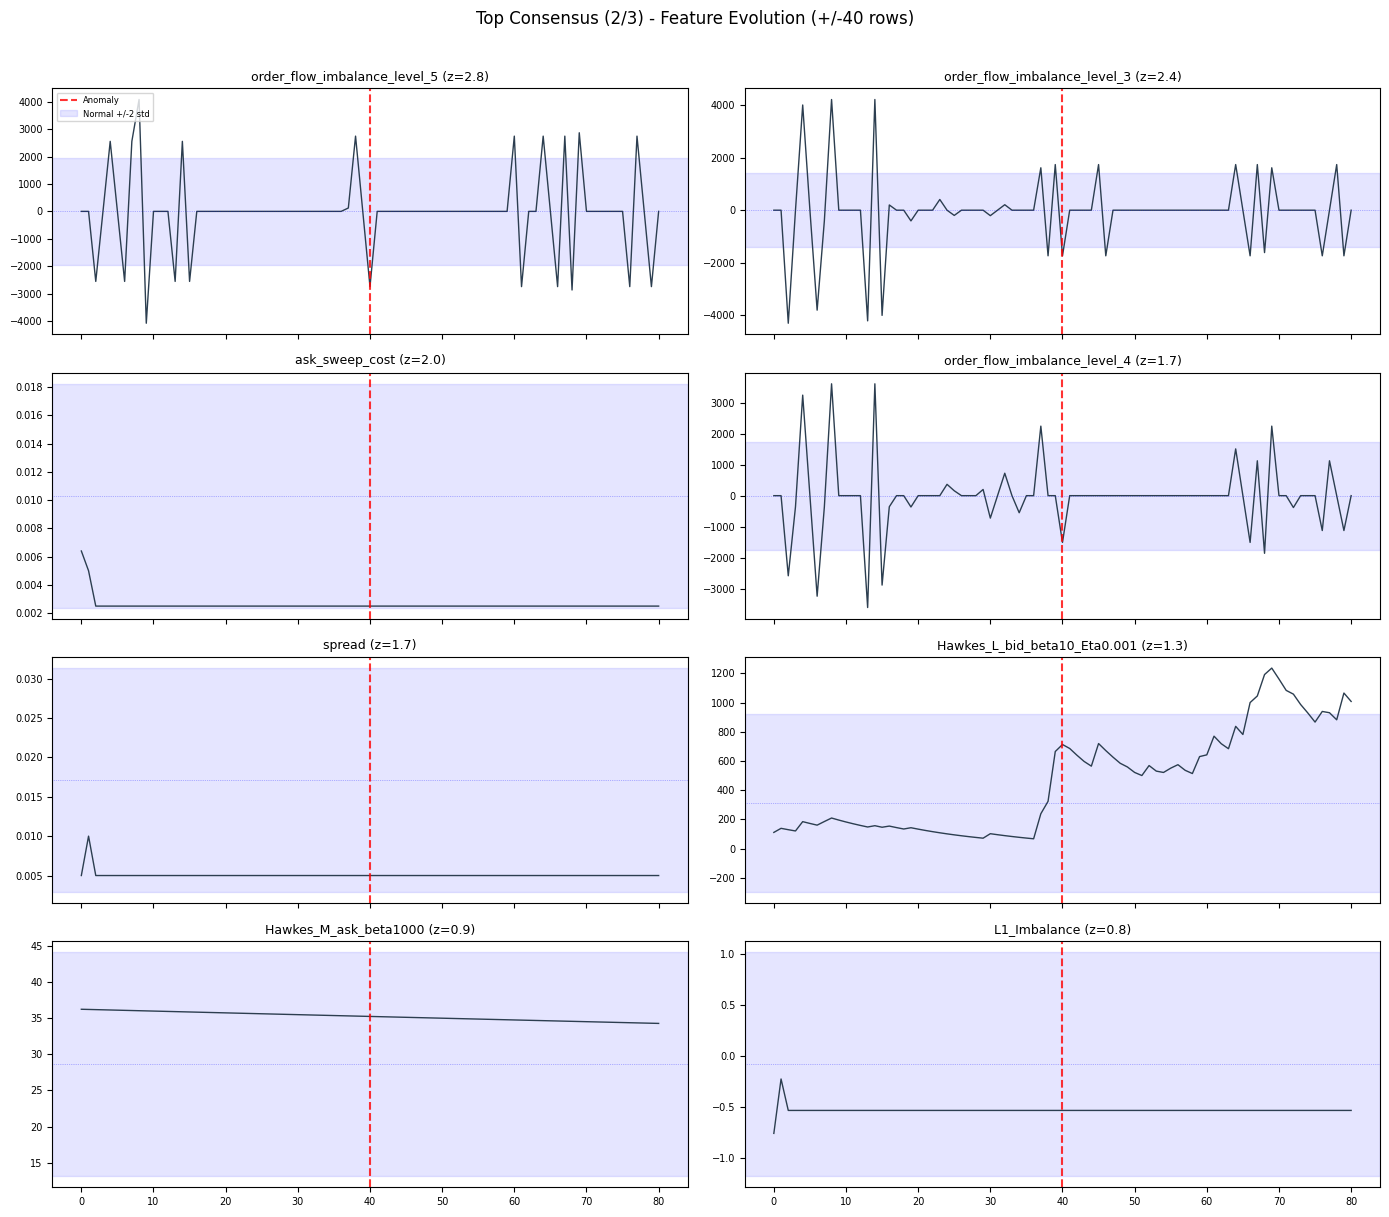


Feature values before / at / after the anomaly:


,Before (-5),Before (-1),At Anomaly,After (+1),After (+5),Delta (before to at),Delta (at to after)
Feature,,,,,,,
order_flow_imbalance_level_5,0.000000,0.000000,-2744.000000,0.000000,0.000000,-2744.000000,2744.000000
order_flow_imbalance_level_3,0.000000,1743.000000,-1743.000000,0.000000,1743.000000,-3486.000000,1743.000000
ask_sweep_cost,0.002500,0.002500,0.002500,0.002500,0.002500,0.000000,0.000000
order_flow_imbalance_level_4,0.000000,0.000000,-1507.000000,0.000000,0.000000,-1507.000000,1507.000000
spread,0.005000,0.005000,0.005000,0.005000,0.005000,0.000000,0.000000
Hawkes_L_bid_beta10_Eta0.001,72.290801,664.741890,712.735532,685.451496,719.260831,47.993642,-27.284036
Hawkes_M_ask_beta1000,35.333696,35.235866,35.211451,35.187053,35.089629,-0.024415,-0.024398
L1_Imbalance,-0.536501,-0.536501,-0.536501,-0.536501,-0.536501,0.000000,0.000000


In [13]:
TOP_K_FEATURES = 8
FEAT_WINDOW = 40

for label, info in anomalies_to_inspect.items():
    seq_idx = info["seq_idx"]
    day_id = info["day_id"]
    model_name = info["model"]

    feat_day = raw_features_days[day_id]

    day_start = day_boundaries[day_id]
    local_seq_idx = seq_idx - day_start
    feat_row = SEQ_LENGTH + local_seq_idx
    feat_row = min(feat_row, len(feat_day) - 1)

    f_start = max(0, feat_row - FEAT_WINDOW)
    f_end = min(len(feat_day), feat_row + FEAT_WINDOW + 1)
    feat_window = feat_day.iloc[f_start:f_end].copy()
    anomaly_offset = feat_row - f_start

    day_preds_combined = pred_matrix[day_start:day_boundaries[day_id + 1]]
    if model_name == "consensus":
        normal_mask_day = day_preds_combined.sum(axis=1) == 0
    elif model_name in MODEL_TYPES:
        mt_idx = MODEL_TYPES.index(model_name)
        normal_mask_day = day_preds_combined[:, mt_idx] == 0
    else:
        normal_mask_day = np.ones(len(day_preds_combined), dtype=bool)

    day_n_seq = day_boundaries[day_id + 1] - day_boundaries[day_id]
    normal_feat_start = SEQ_LENGTH
    normal_feat_end = SEQ_LENGTH + day_n_seq
    normal_feat_indices = np.arange(normal_feat_start, min(normal_feat_end, len(feat_day)))
    if len(normal_mask_day) > len(normal_feat_indices):
        normal_mask_day = normal_mask_day[:len(normal_feat_indices)]
    normal_feats = feat_day.iloc[normal_feat_indices[normal_mask_day]] if normal_mask_day.sum() > 0 else feat_day

    day_mean = normal_feats.mean()
    day_std = normal_feats.std().replace(0, 1e-10)

    anomaly_feat = feat_day.iloc[feat_row]
    z_at_anomaly = ((anomaly_feat - day_mean) / day_std).abs().sort_values(ascending=False)
    top_features = z_at_anomaly.head(TOP_K_FEATURES).index.tolist()

    print(f"\nFEATURE EVOLUTION: {label}")
    print(f"Top {TOP_K_FEATURES} features by |z-score| at anomaly:")
    for feat_name in top_features:
        print(f"  {feat_name:40s}  z={z_at_anomaly[feat_name]:7.2f}  val={anomaly_feat[feat_name]:.6f}")

    n_feat = len(top_features)
    n_cols = 2
    n_rows = math.ceil(n_feat / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
    axes = axes.flatten() if n_feat > 1 else [axes]

    x = np.arange(len(feat_window))
    for ax_i, feat_name in enumerate(top_features):
        ax = axes[ax_i]
        vals = feat_window[feat_name].values
        ax.plot(x, vals, linewidth=1, color="#2c3e50")
        ax.axvline(anomaly_offset, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Anomaly")

        m = day_mean[feat_name]
        s = day_std[feat_name]
        ax.axhspan(m - 2*s, m + 2*s, alpha=0.1, color="blue", label="Normal +/-2 std")
        ax.axhline(m, color="blue", linestyle=":", linewidth=0.5, alpha=0.5)

        ax.set_title(f"{feat_name} (z={z_at_anomaly[feat_name]:.1f})", fontsize=9)
        ax.tick_params(labelsize=7)
        if ax_i == 0:
            ax.legend(fontsize=6, loc="upper left")

    for ax_i in range(n_feat, len(axes)):
        axes[ax_i].set_visible(False)

    fig.suptitle(f"{label} - Feature Evolution (+/-{FEAT_WINDOW} rows)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    delta_rows = []
    offsets = {"Before (-5)": max(0, feat_row - 5),
               "Before (-1)": max(0, feat_row - 1),
               "At Anomaly":  feat_row,
               "After (+1)":  min(len(feat_day) - 1, feat_row + 1),
               "After (+5)":  min(len(feat_day) - 1, feat_row + 5)}

    for feat_name in top_features:
        row_data = {"Feature": feat_name}
        for offset_label, offset_idx in offsets.items():
            row_data[offset_label] = feat_day.iloc[offset_idx][feat_name]
        row_data["Delta (before to at)"] = row_data["At Anomaly"] - row_data["Before (-1)"]
        row_data["Delta (at to after)"]  = row_data["After (+1)"] - row_data["At Anomaly"]
        delta_rows.append(row_data)

    delta_df = pd.DataFrame(delta_rows)
    print(f"\nFeature values before / at / after the anomaly:")
    display(delta_df.set_index("Feature").round(6))

## LOB State Comparison: Before vs After Anomaly

Side-by-side comparison of the full 10-level order book immediately before and after each top anomaly.


Top transformer_ocsvm - LOB State Comparison

  BEFORE (row 771321):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.905,1059.0,40.935,4126.0
2,40.900,1239.0,40.940,3760.0
3,40.895,1717.0,40.945,3700.0
4,40.885,2433.0,40.950,4200.0
5,40.880,4217.0,40.955,3779.0
6,40.875,3837.0,40.960,3522.0
7,40.870,2387.0,40.965,3266.0
8,40.865,132.0,40.970,700.0
9,40.860,1490.0,40.975,1108.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,-339.000000,0.000000,0.000000
3,-0.005000,1188.000000,0.000000,0.000000
4,0.000000,-331.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,331.000000,0.000000,0.000000



  AT ANOMALY (row 771322):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.905,1059.0,40.935,4126.0
2,40.900,900.0,40.940,3760.0
3,40.890,2905.0,40.945,3700.0
4,40.885,2102.0,40.950,4200.0
5,40.880,4217.0,40.955,3779.0
6,40.875,3837.0,40.960,3522.0
7,40.870,2387.0,40.965,3266.0
8,40.865,132.0,40.970,700.0
9,40.860,1821.0,40.975,1108.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,-300.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 771323):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.905,1059.0,40.935,4126.0
2,40.900,600.0,40.940,3760.0
3,40.890,2905.0,40.945,3700.0
4,40.885,2102.0,40.950,4200.0
5,40.880,4217.0,40.955,3779.0
6,40.875,3837.0,40.960,3522.0
7,40.870,2387.0,40.965,3266.0
8,40.865,132.0,40.970,700.0
9,40.860,1821.0,40.975,1108.0


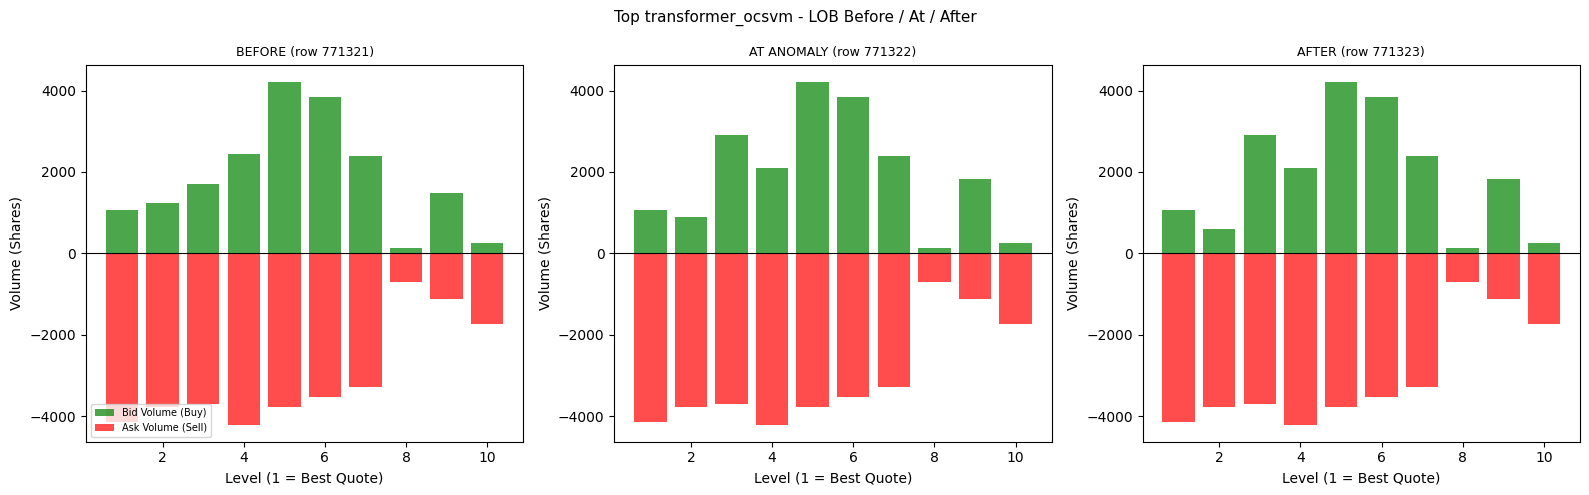


Top pnn - LOB State Comparison

  BEFORE (row 450283):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.890,270.0,40.905,967.0
2,40.875,890.0,40.910,648.0
3,40.875,890.0,40.915,1815.0
4,40.870,3257.0,40.920,1688.0
5,40.860,1931.0,40.925,1445.0
6,40.855,431.0,40.930,1490.0
7,40.860,1931.0,40.935,1958.0
8,40.850,1981.0,40.940,2358.0
9,40.845,681.0,40.945,1422.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,-0.005000,2367.000000,0.000000,-366.000000
4,-0.005000,-1380.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,-0.010000,50.000000,0.000000,0.000000
8,-0.005000,-1300.000000,0.000000,0.000000
9,-0.010000,914.000000,0.000000,0.000000



  AT ANOMALY (row 450284):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.890,270.0,40.905,967.0
2,40.875,890.0,40.910,648.0
3,40.870,3257.0,40.915,1449.0
4,40.865,1877.0,40.920,1688.0
5,40.860,1931.0,40.925,1445.0
6,40.855,431.0,40.930,1490.0
7,40.850,1981.0,40.935,1958.0
8,40.845,681.0,40.940,2358.0
9,40.835,1595.0,40.945,1422.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,-816.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 450285):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.890,270.0,40.905,967.0
2,40.875,890.0,40.910,648.0
3,40.870,2441.0,40.915,1449.0
4,40.865,1877.0,40.920,1688.0
5,40.860,1931.0,40.925,1445.0
6,40.855,431.0,40.930,1490.0
7,40.850,1981.0,40.935,1958.0
8,40.845,681.0,40.940,2358.0
9,40.835,1595.0,40.945,1422.0


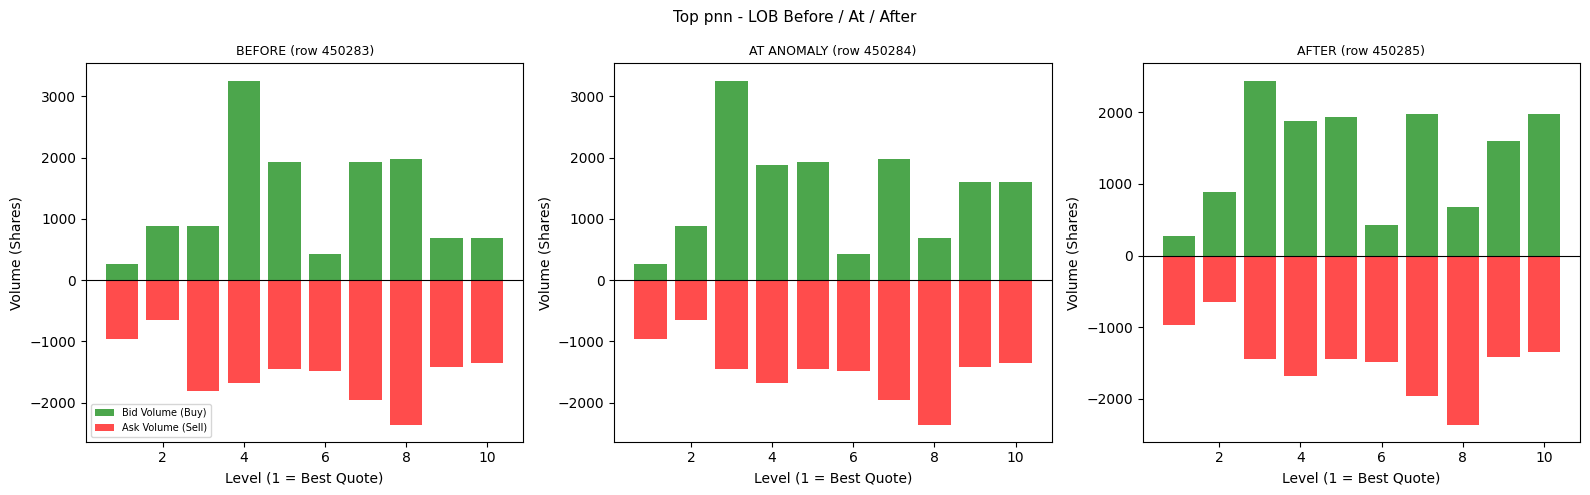


Top prae - LOB State Comparison

  BEFORE (row 991835):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.825,18490.0,40.830,2054.0
2,40.820,1120.0,40.845,2879.0
3,40.785,16727.0,40.850,8836.0
4,40.775,24515.0,40.855,969.0
5,40.765,192.0,40.860,12059.0
6,40.750,20335.0,40.870,12322.0
7,40.730,446.0,40.880,59121.0
8,40.725,64258.0,40.885,600.0
9,40.720,1379.0,40.890,4344.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,-2000.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 991836):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.825,16490.0,40.830,2054.0
2,40.820,1120.0,40.845,2879.0
3,40.785,16727.0,40.850,8836.0
4,40.775,24515.0,40.855,969.0
5,40.765,192.0,40.860,12059.0
6,40.750,20335.0,40.870,12322.0
7,40.730,446.0,40.880,59121.0
8,40.725,64258.0,40.885,600.0
9,40.720,1379.0,40.890,4344.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 991836):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.825,16490.0,40.830,2054.0
2,40.820,1120.0,40.845,2879.0
3,40.785,16727.0,40.850,8836.0
4,40.775,24515.0,40.855,969.0
5,40.765,192.0,40.860,12059.0
6,40.750,20335.0,40.870,12322.0
7,40.730,446.0,40.880,59121.0
8,40.725,64258.0,40.885,600.0
9,40.720,1379.0,40.890,4344.0


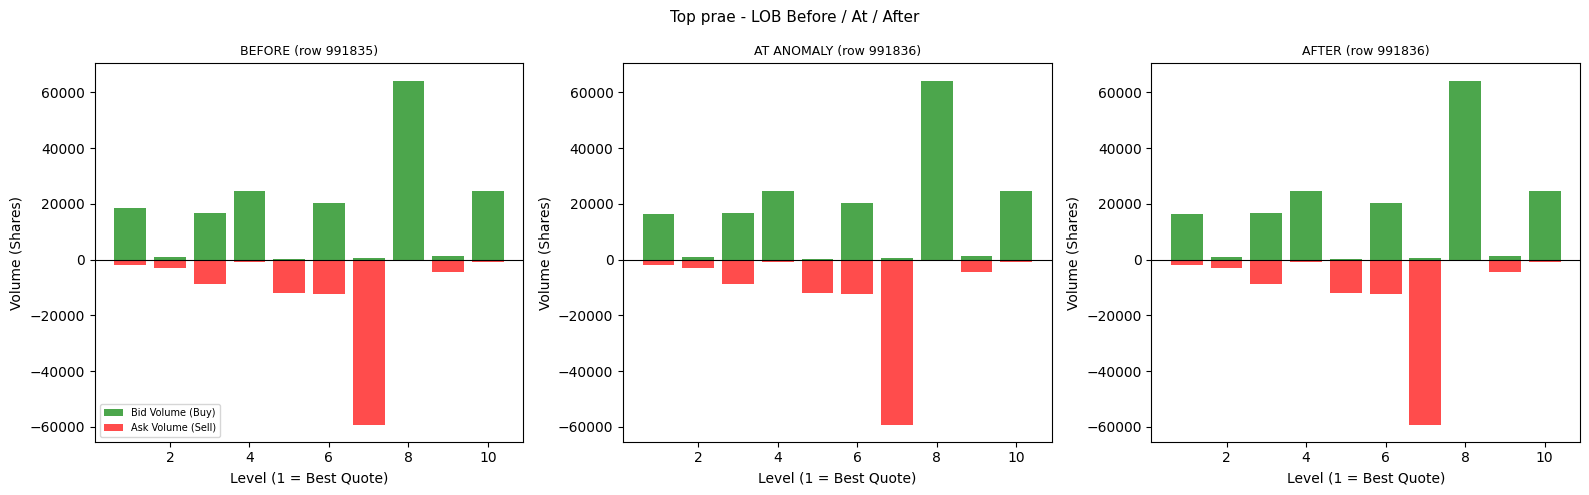


Top Consensus (2/3) - LOB State Comparison

  BEFORE (row 810401):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.750,1949.0,40.760,328.0
2,40.745,2160.0,40.765,687.0
3,40.740,2731.0,40.770,3362.0
4,40.735,3198.0,40.775,2317.0
5,40.730,3522.0,40.780,4534.0
6,40.725,3381.0,40.785,2338.0
7,40.720,2792.0,40.790,3387.0
8,40.715,450.0,40.800,2576.0
9,40.710,3759.0,40.810,1035.0



  Changes BEFORE to AT ANOMALY:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,300.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AT ANOMALY (row 810402):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.750,2249.0,40.760,328.0
2,40.745,2160.0,40.765,687.0
3,40.740,2731.0,40.770,3362.0
4,40.735,3198.0,40.775,2317.0
5,40.730,3522.0,40.780,4534.0
6,40.725,3381.0,40.785,2338.0
7,40.720,2792.0,40.790,3387.0
8,40.715,450.0,40.800,2576.0
9,40.710,3759.0,40.810,1035.0



  Changes AT ANOMALY to AFTER:


,Delta Bid Price,Delta Bid Volume,Delta Ask Price,Delta Ask Volume
Level,,,,
1,0.000000,-83.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000



  AFTER (row 810403):


,Bid Price,Bid Volume,Ask Price,Ask Volume
Level,,,,
1,40.750,2166.0,40.760,328.0
2,40.745,2160.0,40.765,687.0
3,40.740,2731.0,40.770,3362.0
4,40.735,3198.0,40.775,2317.0
5,40.730,3522.0,40.780,4534.0
6,40.725,3381.0,40.785,2338.0
7,40.720,2792.0,40.790,3387.0
8,40.715,450.0,40.800,2576.0
9,40.710,3759.0,40.810,1035.0


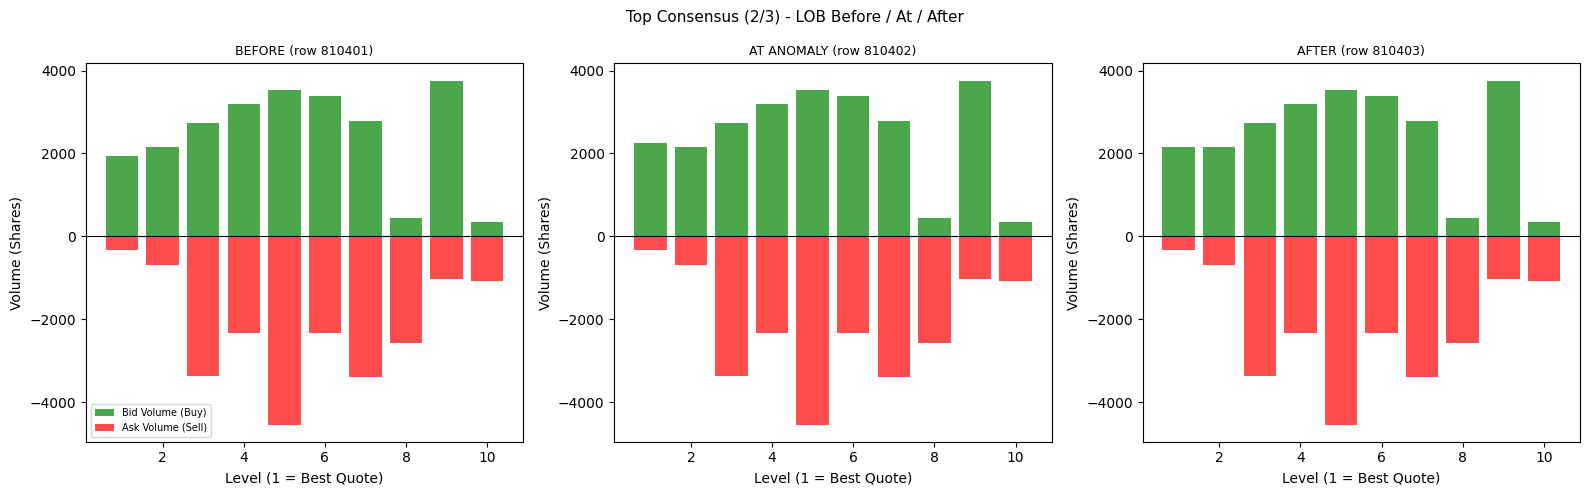

In [14]:
def lob_to_table(df_raw, row_idx, n_levels=LOB_LEVELS):
    """Extract a tidy LOB table for one timestamp."""
    row = df_raw.iloc[row_idx]
    records = []
    for lv in range(1, n_levels + 1):
        records.append({
            "Level": lv,
            "Bid Price":  row.get(f"bid-price-{lv}", np.nan),
            "Bid Volume": row.get(f"bid-volume-{lv}", 0),
            "Ask Price":  row.get(f"ask-price-{lv}", np.nan),
            "Ask Volume": row.get(f"ask-volume-{lv}", 0),
        })
    return pd.DataFrame(records).set_index("Level")


for label, info in anomalies_to_inspect.items():
    day_id = info["day_id"]
    raw_row = min(info["raw_row"], len(raw_lob_days[day_id]) - 1)
    df_raw = raw_lob_days[day_id]

    before_row = max(0, raw_row - 1)
    after_row  = min(len(df_raw) - 1, raw_row + 1)

    lob_before = lob_to_table(df_raw, before_row)
    lob_at     = lob_to_table(df_raw, raw_row)
    lob_after  = lob_to_table(df_raw, after_row)

    print(f"\n{label} - LOB State Comparison")

    delta_before_to_at = pd.DataFrame({
        "Delta Bid Price":  lob_at["Bid Price"]  - lob_before["Bid Price"],
        "Delta Bid Volume": lob_at["Bid Volume"] - lob_before["Bid Volume"],
        "Delta Ask Price":  lob_at["Ask Price"]  - lob_before["Ask Price"],
        "Delta Ask Volume": lob_at["Ask Volume"] - lob_before["Ask Volume"],
    })
    delta_at_to_after = pd.DataFrame({
        "Delta Bid Price":  lob_after["Bid Price"]  - lob_at["Bid Price"],
        "Delta Bid Volume": lob_after["Bid Volume"] - lob_at["Bid Volume"],
        "Delta Ask Price":  lob_after["Ask Price"]  - lob_at["Ask Price"],
        "Delta Ask Volume": lob_after["Ask Volume"] - lob_at["Ask Volume"],
    })

    print(f"\n  BEFORE (row {before_row}):")
    display(lob_before)
    print(f"\n  Changes BEFORE to AT ANOMALY:")
    display(delta_before_to_at.style.applymap(
        lambda v: "color: red; font-weight: bold" if abs(v) > 0 else "", subset=pd.IndexSlice[:, :]))

    print(f"\n  AT ANOMALY (row {raw_row}):")
    display(lob_at)
    print(f"\n  Changes AT ANOMALY to AFTER:")
    display(delta_at_to_after.style.applymap(
        lambda v: "color: red; font-weight: bold" if abs(v) > 0 else "", subset=pd.IndexSlice[:, :]))

    print(f"\n  AFTER (row {after_row}):")
    display(lob_after)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    titles = [f"BEFORE (row {before_row})", f"AT ANOMALY (row {raw_row})", f"AFTER (row {after_row})"]
    tables = [lob_before, lob_at, lob_after]

    for ax, tbl, ttl in zip(axes, tables, titles):
        levels = tbl.index.values
        bv = tbl["Bid Volume"].values
        av = tbl["Ask Volume"].values
        x = np.arange(1, len(levels) + 1)
        ax.bar(x, bv, color="green", alpha=0.7, label="Bid Volume (Buy)")
        ax.bar(x, [-a for a in av], color="red", alpha=0.7, label="Ask Volume (Sell)")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Level (1 = Best Quote)")
        ax.set_ylabel("Volume (Shares)")
        ax.set_title(ttl, fontsize=9)

    axes[0].legend(fontsize=7, loc="lower left")
    fig.suptitle(f"{label} - LOB Before / At / After", fontsize=11)
    plt.tight_layout()
    plt.show()